# Trabajo Práctico Integrador — Análisis de Datos 1B 2026
## FIUBA — CEIA

**Dataset:** Precios Claros — Base SEPA (Cencosud / Vea)  
**Objetivo:** Analizar y preparar los datos para un modelo de Machine Learning supervisado.  
**Problema planteado:** Regresión — Predecir el `productos_precio_lista` de un producto en una sucursal dada.  
**Variable target:** `productos_precio_lista` (variable continua)  

**Estudiantes**:

  - Jose Ignacio Aizpun
  - Victor Hugo Astorga
  - Rodolfo Francisco Di Chiazza
  - Cristhian Marino Pettico
  - Nelson Martin Villagra

---

## 0. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from scipy import stats
from scipy.stats import skew
from sklearn.impute import SimpleImputer
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_regression, mutual_info_regression
)

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

display(Markdown("### 💻 Librerías cargadas correctamente."))

### 💻 Librerías cargadas correctamente.

<div style="font-size: 12px; line-height: 1.35;">

--------------------------------
# Base de datos: Precios Claros - Base SEPA
--------------------------------

SEPA (Sistema Electrónico de Publicidad de Precios Argentinos) reúne los precios de comercios minoristas (grandes establecimientos) de más de 70 mil productos en todo el país, lo que de forma agregada genera una base diaria de aproximadamente 12 millones de registros. https://www.preciosclaros.gob.ar/terminos_y_condiciones.html Contactanos por cualquier tipo consulta, sugerencia y/o reclamo (ej: datos provistos por comercios no fidedignos) al e-mail soportesepa@comercio.gob.ar

</div>

<div style="font-size: 12px; line-height: 1.35;">

## Archivos del paquete

| Nombre | Requerido | Descripción |
|---|---:|---|
| `comercio.csv` | Sí | Datos fundamentales del comercio y las banderas que lo componen. El archivo tendrá tantas filas como banderas tenga el comercio. A su vez, establece la fecha de la última actualización del esquema de datos y la versión de la especificación bajo el cual se publica el paquete. |
| `sucursales.csv` | Sí | Lista de las sucursales del comercio. Los portales web de comercio electrónico deben informarse como una sucursal. |
| `productos.csv` | Sí | Lista de los precios de productos comercializados por el comercio. |

</div>

<div style="font-size: 12px; line-height: 1.35;">

#### Archivo `comercio.csv`

| Campo | Requerido | Descripción |
|---|---:|---|
| `id_comercio` | Sí | El campo `id_comercio` es un identificador único otorgado por la Secretaría de Comercio al momento de dar de alta el mismo. Ejemplo: `"123"` |
| `id_bandera` | Sí | El campo `id_bandera` es un identificador único de una bandera (unidad de negocio, nombre comercial o marca independiente) perteneciente al comercio. En el caso de que el comercio tenga una sola bandera, el `id_bandera` es el número `"1"`. En el caso de que el comercio tenga más de una bandera, el primer id es `"1"` y los siguientes son incrementales (`"1"`, `"2"`, `"3"`, etc.). Ejemplo: `"1"` |
| `comercio_cuit` | Sí | El campo `comercio_cuit` es un número que identifica unívocamente al comercio ante la Administración Federal de Ingresos Públicos (A.F.I.P.). Deberá expresarse como un número sin guiones (C.U.I.T.: Clave Única de Identificación Tributaria). Ejemplo: `"30123456787"` |
| `comercio_razon_social` | Sí | El campo `comercio_razon_social` es un texto que contiene a la razón social del comercio registrada ante la Administración Federal de Ingresos Públicos (AFIP). Ejemplo: `"Supermercado S.R.L."` |
| `comercio_bandera_nombre` | Sí | El campo `comercio_bandera_nombre` es un texto que contiene el nombre comercial utilizado por el comercio para identificar un tipo de formato de comercialización propio. En el caso de que el comercio tenga una sola bandera, el `comercio_bandera_nombre` es igual al nombre de fantasía del comercio. Ejemplo: `"El Rey del Super"` |
| `comercio_bandera_url` | Sí | El campo `comercio_bandera_url` contiene un link a la propiedad digital principal de la bandera. La URL debe incluir el protocolo de conexión. Ejemplo: `"http://www.el-rey-del-super.com.ar"` |
| `comercio_ultima_actualizacion` | Sí | El campo `comercio_ultima_actualizacion` es un texto que contiene la fecha y hora de la última actualización de los archivos del paquete SEPA. El texto debe seguir el estándar ISO 8601 que respeta el siguiente formato: `YYYY-MM-DDTHH:MM:SS[.mmmmmmm][+HH:MM]`. Ejemplo: `"2016-02-29T14:04:00-03:00"` |
| `comercio_version_sepa` | Sí | El campo `comercio_version_sepa` es un número que indica la versión del modelo de datos del paquete SEPA bajo la cual se publican los 3 archivos CSV. Ejemplo: `"1.0"` |

---

#### Archivo `sucursales.csv`

| Campo | Requerido | Descripción |
|---|---:|---|
| `id_comercio` | Sí | El campo `id_comercio` es un identificador único otorgado por la Secretaría de Comercio Interior al momento de dar de alta el mismo. Ejemplo: `"123"` |
| `id_bandera` | Sí | El campo `id_bandera` es un identificador único de una bandera (unidad de negocio, nombre comercial o marca independiente) perteneciente al comercio. En el caso de que el comercio tenga una sola bandera, el `id_bandera` es el número `"1"`. En el caso de que el comercio tenga más de una bandera el primer id es `"1"` y los siguientes son incrementales (`"1"`, `"2"`, `"3"`, etc.). Ejemplo: `"1"` |
| `id_sucursal` | Sí | El campo `id_sucursal` es un identificador único de la sucursal. El mismo es un código interno propio del comercio y debe ser estable a lo largo del tiempo. Lo indicado en este apartado también será de aplicación para las sucursales web. Ejemplo: `"7"` |
| `sucursales_nombre` | Sí | El campo `sucursales_nombre` es un nombre por el cual se reconoce a la sucursal. Ejemplo: `"Sucursal Pompeya"` o `"Minimercado La Nueva Argentina"` |
| `sucursales_tipo` | Sí | El campo `sucursales_tipo` es una categorización de la sucursal según las características de su línea de cajas, definido por la cantidad de líneas de caja: **Hipermercado**: más de 15 cajas. **Supermercado**: entre 4 y 15 cajas. **Autoservicio**: entre 1 y 3 cajas. **Tradicional**: Mostrador sin línea de caja. **Web**. Ejemplo: `"Hipermercado"` |
| `sucursales_calle` | Sí | El campo `sucursales_calle` es el nombre de la calle donde se encuentra la puerta principal de la sucursal. El campo se debe encontrar normalizado (sólo debe incluir el nombre de la calle, sin número, sin pisos, sin observaciones, etc.). Para la sucursal web, indicar el nombre del sitio web de compra online. Ejemplo: `"La Nueva Argentina Online"` |
| `sucursales_numero` | Sí | El campo `sucursales_numero` es la numeración válida de la puerta principal de la sucursal (sólo debe incluir un número, sin calle, sin piso, sin observaciones, etc.). En caso de que el domicilio no posea número este campo quedará vacío. Ejemplo: `"250"`. Para la sucursal web, este campo quedará vacío. |
| `sucursales_latitud` | Sí | El campo `sucursales_latitud` corresponde a la latitud geográfica de la puerta principal de la sucursal, expresada de acuerdo al sistema de referencia WGS84. Este valor se expresará en números, redondeando en seis decimales y utilizando punto (`"."`) como separador de decimales. Ejemplo: `"-34,603722"`. Para la sucursal web, este campo quedará vacío. |
| `sucursales_longitud` | Sí | El campo `sucursales_longitud` corresponde a la longitud geográfica de la puerta principal de la sucursal, expresada de acuerdo al sistema de referencia WGS84. Este valor se expresará en números, redondeando en seis decimales y utilizando punto (`"."`) como separador de decimales. Ejemplo: `"-58,381592"`. Para la sucursal web, este campo quedará vacío. |
| `sucursales_observaciones` | No | El campo `sucursales_observaciones` es un texto que contiene observaciones adicionales sobre la localización de la sucursal, cuando estas sean necesarias o útiles para su fácil localización. Ejemplo: una sucursal dentro de un centro comercial podría incluir aquí indicaciones como el número de local, el piso, el nombre del centro comercial y otras (`"Local nro. 123 – Piso 4 - Centro Comercial Nuevo Shopping - Contiguo al local A"`). Este es un campo de texto libre, pero se recomienda utilizar guiones medios `"-"` para separar las indicaciones. Para la sucursal web, este campo debe ser completado con la página web de la bandera. |
| `sucursales_barrio` | No | El campo `sucursales_barrio` contiene el nombre del barrio o subdivisión de la localidad donde se encuentre ubicada la sucursal. Ejemplo: `"Villa Lugano"`. Para la/s sucursal/es web, también se deberá especificar el barrio correspondiente. |
| `sucursales_codigo_postal` | Sí | El campo `sucursales_codigo_postal` es un número que corresponde al código postal de la sucursal, sin letras. Ejemplo: `1426` (en lugar de `"C1426BMD"`). Para la/s sucursal/es web, también se deberá especificar el código correspondiente. |
| `sucursales_localidad` | Sí | El campo `sucursales_localidad` contiene la localidad donde se encuentra ubicada la sucursal. Ejemplo: `"Mar de Ajó"`. Para la/s sucursal/es web, también se deberá especificar la localidad correspondiente. |
| `sucursales_provincia` | Sí | El campo `sucursales_provincia` contiene la provincia donde se encuentra ubicada la sucursal. La nomenclatura a utilizar será la indicada por la norma ISO 3166-2. Ejemplo: `"AR-B"` identifica a la provincia de Buenos Aires. Para la/s sucursal/es web, también se deberá especificar la provincia correspondiente. |
| `sucursales_lunes_horario_atencion` | Sí | El campo `sucursales_lunes_horario_atencion` describe los horarios de atención de la sucursal el día lunes. La hora será expresada de 00:00 a 24:00 HS atendiendo al siguiente formato `HH:mm`. En los casos que el horario de atención sea corrido se completará hora de apertura a hora de cierre siguiendo el siguiente formato `"HH:mm a HH:mm"`. Para los casos en que se trabaje en horario cortado se separarán los turnos por un espacio guión medio espacio (`" - "`), es decir, `"HH:mm a HH:mm - HH:mm a HH:mm"`. En los casos que el comercio se encuentre cerrado el día lunes se debe completar el campo con la palabra `"cerrado"`. Las horas deben tener CINCO (5) dígitos en formato `HH:mm`. No se deben incluir espacios dentro del texto que especifica una hora y los números que tengan menos de DOS (2) dígitos deben estar precedidos por un cero (`"08"` en lugar de `"8"`). Los valores nulos o faltantes se interpretarán como errores en la información. Para la sucursal web, este campo quedará vacío. |
| `sucursales_martes_horario_atencion` | Sí | Mismo criterio de formato y validación que `sucursales_lunes_horario_atencion`, aplicado al día martes. |
| `sucursales_miercoles_horario_atencion` | Sí | Mismo criterio de formato y validación que `sucursales_lunes_horario_atencion`, aplicado al día miércoles. |
| `sucursales_jueves_horario_atencion` | Sí | Mismo criterio de formato y validación que `sucursales_lunes_horario_atencion`, aplicado al día jueves. |
| `sucursales_viernes_horario_atencion` | Sí | Mismo criterio de formato y validación que `sucursales_lunes_horario_atencion`, aplicado al día viernes. |
| `sucursales_sabado_horario_atencion` | Sí | Mismo criterio de formato y validación que `sucursales_lunes_horario_atencion`, aplicado al día sábado. |
| `sucursales_domingo_horario_atencion` | Sí | Mismo criterio de formato y validación que `sucursales_lunes_horario_atencion`, aplicado al día domingo. |
---

#### Archivo `productos.csv`

| Campo | Requerido | Descripción |
|---|---:|---|
| `id_comercio` | Sí | El campo `id_comercio` es un identificador único otorgado por la Secretaría de Comercio Interior al momento de dar de alta el mismo. Ejemplo: `"123"` |
| `id_bandera` | Sí | El campo `id_bandera` es un identificador único de una bandera (unidad de negocio, nombre comercial o marca independiente) perteneciente al comercio. En el caso de que el comercio tenga una sola bandera, el `id_bandera` es el número `"1"`. En caso de que el comercio tenga más de una bandera el primer id es `"1"` y los siguientes son incrementales (`"1"`, `"2"`, `"3"`, etc.). Ejemplo: `"1"` |
| `id_sucursal` | Sí | El campo `id_sucursal` es un identificador único de la sucursal. El mismo es un código interno propio del comercio y debe ser estable a lo largo del tiempo. Ejemplo: `"7"` |
| `id_producto` | Sí | El campo `id_producto` es un identificador único del producto. El mismo es el código EAN (GTIN 8 o GTIN 13), UPC-A (GTIN 12) o un código interno propio del comercio de TRECE (13) dígitos de largo, cuando ninguno de los anteriores sea de posible aplicación. En el caso de que el comercio deba utilizar un código propio para la identificación del producto, este debe ser estable en el tiempo, único para todas las sucursales del comercio y tener TRECE (13) dígitos de largo, incorporando ceros a la izquierda de ser necesario. Ejemplo: (A) `"0779027200550"` (B) `"0000000000001"` |
| `productos_ean` | Sí | El campo `productos_ean` define si el valor en el campo `id_producto` corresponde al estándar EAN (GTIN 8 o GTIN 13), UPC-A (GTIN 12) —en cuyo caso adopta el valor `"1"`— o es un identificador único del comercio para ese producto (en cuyo caso adopta el valor `"0"`). Ejemplo: `"0"` |
| `productos_descripcion` | Sí | El campo `productos_descripcion` es una descripción completa del producto, que incluye toda la información necesaria para que un Consumidor lo identifique unívocamente (descripción, marca, presentación, cantidad, unidad de medida, etc.). Ejemplo: `"Aceite oliva Freir aerosol 120ml"` |
| `productos_cantidad_presentacion` | Sí | El campo `productos_cantidad_presentacion` contiene la cantidad de producto que se vende en función de su presentación de venta en términos de su `"unidad de medida"`. En el caso de que el producto se venda a granel (Ej.: papas a granel que el Consumidor debe pesar en la balanza) la cantidad de presentación será `"1"`. Ejemplo: `"120"` |
| `productos_unidad_medida_presentacion` | Sí | El campo `productos_unidad_medida_presentacion` contiene la unidad de medida en la que se expresa la cantidad de producto vendido en sus diferentes presentaciones. Volumen: l (litro), hl (hectolitro), ml (mililitro), m3 (metro cúbico), cm3 (centímetro cúbico). Peso: kg (kilogramo), gr o g (gramo). Longitud: m (metro), dm (decímetro), cm (centímetro). Otros: unidad, paquete. Ejemplo: `"ml"` |
| `productos_marca` | Sí | El campo `productos_marca` contiene el nombre comercial de la marca del producto. Ejemplo: `"Freir"` |
| `productos_precio_lista` | Sí | El campo `productos_precio_lista` indica el valor del producto para la venta al consumidor final, sin considerar deducciones por descuentos de ningún tipo. Este valor debe representar aquel precio al que cualquier consumidor puede adquirir el producto sin ningún tipo de descuento, con cualquier medio de pago aceptado por el comercio, sin utilizar ninguna tarjeta de fidelidad, sin considerar segmentación del consumidor (Ej.: jubilado, estudiante, etc.) y sin consideraciones específicas de ningún tipo. Este valor se expresará en números, redondeando en dos decimales y utilizando punto (`"."`) como separador de decimales. Ejemplo: `"111.66"` |
| `productos_precio_referencia` | Sí | El campo `productos_precio_referencia` indica el valor del producto según la unidad de medida de referencia, es decir, precio por `"lt"` (litro), precio por `"kg"` (kilogramo) o por `"m"` (metro), entre otros (ver detalle en la descripción del campo `productos_unidad_medida`). Este valor se expresará en números, redondeando en dos decimales y utilizando punto (`"."`) como separador de decimales. Ejemplo: `"200.00"` |
| `productos_cantidad_referencia` | Sí | El campo `productos_cantidad_referencia` contiene la cantidad de producto en la que se expresa su precio según la unidad de medida de referencia. Ejemplo: `"1"` o `"100"` |
| `productos_unidad_medida_referencia` | Sí | El campo `productos_unidad_medida_referencia` contiene la unidad de medida de referencia. Volumen: l (litro), hl (hectolitro), ml (mililitro), m3 (metro cúbico), cm3 (centímetro cúbico). Peso: kg (kilogramo), gr o g (gramo). Longitud: m (metro), dm (decímetro), cm (centímetro). Otros: unidad, paquete. Ejemplo: `"l"` |
| `productos_precio_unitario_promo1` | No | El campo `productos_precio_unitario_promo1` indica el precio de la unidad de producto sujeta a la promoción número 1, indicado en la Disposición como `"Precio unitario correspondiente a promoción de alcance general"`. Este precio sólo hace referencia a aquellos descuentos que se aplican al producto sin estar sujetos a segmentación del consumidor (Ej.: jubilados, estudiantes, empleado Empresa `"X"` etc.), medio de pago que utilice o a las tarjetas de fidelización que pueda poseer. En este campo se permitirá consignar precios con descuentos (A) por producto o (B) por categoría de producto o (C) por marca o (D) por cantidad, todas condiciones excluyentes entre sí. Este valor se expresará en números, redondeando en dos decimales y utilizando punto (`"."`) como separador de decimales. Ejemplo: `"73.70"` |
| `productos_leyenda_promo1` | No | El campo `productos_leyenda_promo1` es un texto que describe la promoción vigente que da lugar al precio indicado en el campo `productos_precio_unitario_promo1`. La misma debe incluir la fecha de vigencia de la promoción y el stock de unidades disponibles en caso de corresponder. Ejemplo: `"3x2 - Lleva 3 productos y paga 2 - Vigencia: Desde el 24/12/16 Hasta el 31/12/16 - Stock: Hasta agotar las 100.000 unidades"` |
| `productos_precio_unitario_promo2` | No | El campo `productos_precio_unitario_promo2` indica el valor de la unidad de producto sujeta a la promoción número 2, indicado en la Disposición como `"Precio unitario correspondiente a promoción especial"`. En este campo se permitirá consignar precios con descuentos que se aplican al producto por una o más condiciones de alcance general (por producto, por categoría de producto, por marca o por cantidad) o particular (tarjeta de fidelidad, medios de pago, segmentación del consumidor -jubilados, estudiantes, etc.-). Este valor se expresará en números, redondeando en dos decimales y utilizando punto (`"."`) como separador de decimales. Ejemplo: `"78.16"` |
| `productos_leyenda_promo2` | No | El campo `productos_leyenda_promo2` es un texto que describe la promoción vigente que da lugar al precio producido por `productos_precio_unitario_promo2`. La misma debe incluir la fecha de vigencia, las condiciones a cumplir para efectivizar el precio informado como `"Especial"` y el stock de unidades disponibles en caso de corresponder. Ejemplo: `"50% de descuento en la segunda unidad, más 15% de descuento con tarjeta fidelidad". Vigencia: Desde el 24/12/2016 Hasta el 31/12/2016. Stock: Hasta agotar las 100.000 unidades.` |

</div>


<div style="font-size: 12px; line-height: 1.35;">

## Campos compartidos entre archivos

| Campo | comercio.csv | sucursales.csv | productos.csv |
|---|---:|---:|---:|
| `id_comercio` | ✓ | ✓ | ✓ |
| `id_bandera` | ✓ | ✓ | ✓ |
| `id_sucursal` |  | ✓ | ✓ |

</div>

---

#### Base de provincias ISO 3166-2

| sucursales_provincia | provincia              |
|----------------------|------------------------|
| AR-C                 | CABA                   |
| AR-B                 | Buenos Aires           |
| AR-K                 | Catamarca              |
| AR-H                 | Chaco                  |
| AR-U                 | Chubut                 |
| AR-X                 | Córdoba                |
| AR-W                 | Corrientes             |
| AR-E                 | Entre Ríos             |
| AR-P                 | Formosa                |
| AR-Y                 | Jujuy                  |
| AR-L                 | La Pampa               |
| AR-F                 | La Rioja               |
| AR-M                 | Mendoza                |
| AR-N                 | Misiones               |
| AR-Q                 | Neuquén                |
| AR-R                 | Río Negro              |
| AR-A                 | Salta                  |
| AR-J                 | San Juan               |
| AR-D                 | San Luis               |
| AR-Z                 | Santa Cruz             |
| AR-S                 | Santa Fe               |
| AR-G                 | Santiago del Estero    |
| AR-V                 | Tierra del Fuego       |
| AR-T                 | Tucumán                |

---
## 1. Carga y exploración inicial de los datos

El dataset SEPA está compuesto por tres archivos CSV separados por `|`:
- `comercio_unificado.csv`: datos del comercio y sus banderas.
- `sucursales_unificado.csv`: lista de sucursales con geolocalización y horarios.
- `productos_unificado.csv`: precios de productos por sucursal (~1.4M registros).


In [2]:
# --- Carga de los tres archivos ---
comercio_df = pd.read_csv('comercio_unificado.csv', sep='|')
sucursales_df = pd.read_csv('sucursales_unificado.csv', sep='|')
productos_df = pd.read_csv('productos_unificado.csv', sep='|', low_memory=False)
display(Markdown("### 📑 Carga de los tres archivos."))
print(f'comercio_df: {comercio_df.shape}')
print(f'sucursales_df: {sucursales_df.shape}')
print(f'productos_df: {productos_df.shape}')

### 📑 Carga de los tres archivos.

comercio_df: (1, 8)
sucursales_df: (278, 21)
productos_df: (1426356, 24)


In [3]:
# --- Vista rápida de cada tabla ---
# 1. Título bonito con Markdown
display(Markdown("### 🛒 Vista rápida: `COMERCIO`"))
# 2. Mostramos las primeras filas (automáticamente renderizado como tabla HTML)
display(comercio_df.head())
# 3. Subtítulo
display(Markdown("#### 📋 Información de las Columnas"))
# 4. Formateamos las columnas y sus tipos como un DataFrame para que se vea como tabla
info_df = comercio_df.dtypes.to_frame(name="Tipo de Dato").reset_index()
info_df.columns = ["Columna", "Tipo de Dato"]
display(info_df)

### 🛒 Vista rápida: `COMERCIO`

,id_comercio,id_bandera,comercio_cuit,comercio_razon_social,comercio_bandera_nombre,comercio_bandera_url,comercio_ultima_actualizacion,comercio_version_sepa
0,9,1,30590360763,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,1.0


#### 📋 Información de las Columnas

,Columna,Tipo de Dato
0,id_comercio,int64
1,id_bandera,int64
2,comercio_cuit,int64
3,comercio_razon_social,object
4,comercio_bandera_nombre,object
5,comercio_bandera_url,object
6,comercio_ultima_actualizacion,object
7,comercio_version_sepa,float64


In [4]:
# 1. Título bonito con Markdown
display(Markdown("### 🏢 Vista rápida: `SUCURSALES`"))
# 2. Mostramos las primeras filas
display(sucursales_df.head())
# 3. Extraemos las dimensiones y lo renderizamos de forma limpia
filas, columnas = sucursales_df.shape
display(Markdown(f"#### 📐 Dimensiones\n**{filas}** filas y **{columnas}** columnas"))
# 4. Formato de tabla para las columnas
display(Markdown("#### 📋 Información de las Columnas"))
info_df = sucursales_df.dtypes.to_frame(name="Tipo de Dato").reset_index()
info_df.columns = ["Columna", "Tipo de Dato"]
display(info_df)

### 🏢 Vista rápida: `SUCURSALES`

,id_comercio,id_bandera,id_sucursal,sucursales_nombre,sucursales_tipo,sucursales_calle,sucursales_numero,sucursales_latitud,sucursales_longitud,sucursales_observaciones,...,sucursales_codigo_postal,sucursales_localidad,sucursales_provincia,sucursales_lunes_horario_atencion,sucursales_martes_horario_atencion,sucursales_miercoles_horario_atencion,sucursales_jueves_horario_atencion,sucursales_viernes_horario_atencion,sucursales_sabado_horario_atencion,sucursales_domingo_horario_atencion
0,9,1,902,Lainez,Supermercado,12 DE SEPTIEMBRE Y LAINEZ,0,-38.9562,-68.0664,NaN,...,8300,NEUQUEN,AR-Q,09:00 a 21:00,09:00 a 21:00,09:00 a 21:00,09:00 a 21:00,09:00 a 21:00,09:00 a 21:00,08:00 a 22:00
1,9,1,910,Vea Roca I,Supermercado,Ruta 22 y Gobernador Viterbori,0,-39.0451,-67.5778,NaN,...,8332,GENERAL ROCA,AR-R,09:00 a 21:30,09:00 a 21:30,09:00 a 21:30,09:00 a 21:30,09:00 a 21:30,09:00 a 21:30,08:00 a 22:00
2,9,1,912,Junin SM 912,Supermercado,ITUZAINGO,43,-34.5832,-60.9565,NaN,...,6000,JUNIN,AR-B,08:00 a 21:00,08:00 a 21:00,08:00 a 21:00,08:00 a 21:00,08:00 a 21:00,08:00 a 21:00,08:30 a 13:30 y 17:00 a 21:00
3,9,1,914,Malargüe,Supermercado,Calle Av.Roca s/n entre Villa del Milagro y Calle,0,-35.4752,-69.5916,NaN,...,5613,MALARGUE,AR-M,09:00 a 13:00 y 17:00 a 21:00,09:00 a 13:00 y 17:00 a 21:00,09:00 a 13:00 y 17:00 a 21:00,09:00 a 13:00 y 17:00 a 21:00,09:00 a 13:00 y 17:00 a 21:00,09:00 a 13:00 y 17:00 a 21:00,08:00 a 22:00
4,9,2,916,SM 916 Gorostiaga,Supermercado,GOROSTIAGA JOSE BENJAMIN.,1636,-34.5655,-58.4368,NaN,...,1426,CIUDAD AUTONOMA BUENOS AIRES,AR-C,08:00 a 21:30,08:00 a 21:30,08:00 a 21:30,08:00 a 21:30,08:00 a 21:30,08:00 a 21:30,08:00 a 22:00


#### 📐 Dimensiones
**278** filas y **21** columnas

#### 📋 Información de las Columnas

,Columna,Tipo de Dato
0,id_comercio,int64
1,id_bandera,int64
2,id_sucursal,int64
3,sucursales_nombre,object
4,sucursales_tipo,object
5,sucursales_calle,object
6,sucursales_numero,int64
7,sucursales_latitud,float64
8,sucursales_longitud,float64
9,sucursales_observaciones,float64


In [5]:
# 1. Título bonito con Markdown
display(Markdown("### 📦 Vista rápida: `PRODUCTOS` (primeras filas)"))
# 2. Mostramos las primeras filas
display(productos_df.head())
# 3. Extraemos las dimensiones y lo renderizamos de forma limpia
filas, columnas = productos_df.shape
display(Markdown(f"#### 📐 Dimensiones\n**{filas}** filas y **{columnas}** columnas"))
# 4. Formato de tabla para las columnas
display(Markdown("#### 📋 Información de las Columnas"))
info_df = productos_df.dtypes.to_frame(name="Tipo de Dato").reset_index()
info_df.columns = ["Columna", "Tipo de Dato"]
display(info_df)

### 📦 Vista rápida: `PRODUCTOS` (primeras filas)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,...,productos_leyenda_promo1,productos_preciounitario_promo2,productos_leyenda_promo2,dia_1,dia_2,dia_3,dia_4,dia_5,dia_6,dia_7
0,9,1,122,1038,0,Botella coca cola PVC-1.5-lt.,1.5,lt.,SIN MARCA,0.31,...,NaN,NaN,NaN,0,0,0,1,1,0,0
1,9,1,173,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,NaN,NaN,NaN,0,0,0,1,1,0,0
2,9,1,400,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,NaN,NaN,NaN,0,0,0,1,1,0,0
3,9,1,868,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,NaN,NaN,NaN,0,0,0,1,1,0,0
4,9,1,180,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,NaN,NaN,NaN,0,0,0,1,1,0,0


#### 📐 Dimensiones
**1426356** filas y **24** columnas

#### 📋 Información de las Columnas

,Columna,Tipo de Dato
0,id_comercio,int64
1,id_bandera,int64
2,id_sucursal,int64
3,id_producto,int64
4,productos_ean,int64
5,productos_descripcion,object
6,productos_cantidad_presentacion,float64
7,productos_unidad_medida_presentacion,object
8,productos_marca,object
9,productos_precio_lista,float64


### 1.1 Unión de datasets

Unimos los tres archivos usando las claves compartidas:
- `productos` ↔ `sucursales`: por `id_comercio`, `id_bandera`, `id_sucursal`
- `sucursales` ↔ `comercio`: por `id_comercio`, `id_bandera`

In [6]:
# Primero unimos productos con sucursales
df = productos_df.merge(
    sucursales_df,
    on=['id_comercio', 'id_bandera', 'id_sucursal'],
    how='left'
)

# Luego unimos con comercio
df = df.merge(
    comercio_df,
    on=['id_comercio', 'id_bandera'],
    how='left'
)

display(Markdown(f"#### ➕ Dataset unificado: {df.shape}"))
display(df.head())

#### ➕ Dataset unificado: (1426356, 48)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,...,sucursales_jueves_horario_atencion,sucursales_viernes_horario_atencion,sucursales_sabado_horario_atencion,sucursales_domingo_horario_atencion,comercio_cuit,comercio_razon_social,comercio_bandera_nombre,comercio_bandera_url,comercio_ultima_actualizacion,comercio_version_sepa
0,9,1,122,1038,0,Botella coca cola PVC-1.5-lt.,1.5,lt.,SIN MARCA,0.31,...,08:30 a 21:00,08:30 a 21:00,08:30 a 21:00,09:00 a 21:00,3.059036e+10,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,1.0
1,9,1,173,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,08:30 a 21:30,08:30 a 21:30,08:30 a 21:30,08:00 a 22:00,3.059036e+10,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,1.0
2,9,1,400,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,08:30 a 13:00 y 17:00 a 21:00,08:30 a 13:00 y 17:00 a 21:00,08:30 a 21:00,08:00 a 22:00,3.059036e+10,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,1.0
3,9,1,868,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,08:30 a 13:00 y 17:00 a 21:00,08:30 a 13:00 y 17:00 a 21:00,08:30 a 21:30,08:00 a 22:00,3.059036e+10,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,1.0
4,9,1,180,1052,0,botella coca cola x 2 lt. PVC-2-lt.,2.0,lt.,SIN MARCA,1.19,...,09:00 a 21:00,09:00 a 21:00,09:00 a 21:00,08:00 a 22:00,3.059036e+10,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,1.0


Procdemos con un agregado de variables sinteticas para claridad de nombres de provincias:

In [7]:
# ─────────────────────────────────────────────────────────────
# VARIABLE SINTÉTICA: provincia_nombre y provincia_region
# Fuente: ISO 3166-2:AR (estándar usado por la especificación SEPA)
# ─────────────────────────────────────────────────────────────

PROVINCIAS_ISO = {
    'AR-B': 'Buenos Aires',
    'AR-C': 'CABA',
    'AR-K': 'Catamarca',
    'AR-H': 'Chaco',
    'AR-U': 'Chubut',
    'AR-X': 'Córdoba',
    'AR-W': 'Corrientes',
    'AR-E': 'Entre Ríos',
    'AR-P': 'Formosa',
    'AR-Y': 'Jujuy',
    'AR-L': 'La Pampa',
    'AR-F': 'La Rioja',
    'AR-M': 'Mendoza',
    'AR-N': 'Misiones',
    'AR-Q': 'Neuquén',
    'AR-R': 'Río Negro',
    'AR-A': 'Salta',
    'AR-J': 'San Juan',
    'AR-D': 'San Luis',
    'AR-Z': 'Santa Cruz',
    'AR-S': 'Santa Fe',
    'AR-G': 'Santiago del Estero',
    'AR-V': 'Tierra del Fuego',
    'AR-T': 'Tucumán',
}

# Agrupación en macrorregiones con correlación de nivel de precios
REGION_MAP = {
    'Buenos Aires':                     'Centro',
    'CABA':                             'Centro',
    'Córdoba':                          'Centro',
    'Santa Fe':                         'Centro',
    'Entre Ríos':                       'Centro',
    'Mendoza':                          'Cuyo',
    'San Juan':                         'Cuyo',
    'San Luis':                         'Cuyo',
    'Jujuy':                            'NOA',
    'Salta':                            'NOA',
    'Tucumán':                          'NOA',
    'Catamarca':                        'NOA',
    'La Rioja':                         'NOA',
    'Santiago del Estero':              'NOA',
    'Formosa':                          'NEA',
    'Chaco':                            'NEA',
    'Misiones':                         'NEA',
    'Corrientes':                       'NEA',
    'Neuquén':                          'Patagonia',
    'Río Negro':                        'Patagonia',
    'Chubut':                           'Patagonia',
    'Santa Cruz':                       'Patagonia',
    'La Pampa':                         'Patagonia',
    'Tierra del Fuego':                 'Patagonia',
}

# Aplicar mapeos al dataset principal
if 'sucursales_provincia' in df.columns:
    df['provincia_nombre'] = df['sucursales_provincia'].map(PROVINCIAS_ISO)
    df['provincia_region'] = df['provincia_nombre'].map(REGION_MAP).fillna('Desconocida')

    display(Markdown(f'#### 🇦🇷 Provincias por nombre — valores únicos: {df["provincia_nombre"].nunique()}'))
    print(df['provincia_nombre'].value_counts())
    display(Markdown(f'\n#### 🇦🇷 Provincia por region — distribución:'))
    print(df['provincia_region'].value_counts())
else:
    print('Columna sucursales_provincia no encontrada.')


#### 🇦🇷 Provincias por nombre — valores únicos: 19

provincia_nombre
Buenos Aires           407060
CABA                   254446
Córdoba                222593
Mendoza                196511
Tucumán                 65023
Salta                   59394
San Juan                44334
Entre Ríos              20330
Catamarca               20295
Chubut                  18835
Santa Fe                18420
San Luis                16002
Río Negro               15694
Santiago del Estero     14925
Jujuy                   14210
La Rioja                11402
Neuquén                 11304
Corrientes              10444
Chaco                    5134
Name: count, dtype: int64



#### 🇦🇷 Provincia por region — distribución:

provincia_region
Centro       922849
Cuyo         256847
NOA          185249
Patagonia     45833
NEA           15578
Name: count, dtype: int64


Informacion faltante extraida de https://www.jumbomas.com.ar/terminosycondiciones

### 1.2 Descripción general del dataset unificado

In [8]:
display(Markdown("#### 📋 Detalle pormenorizado del dataset"))
print(f'Número de observaciones: {df.shape[0]:,}')
print(f'Número de variables: {df.shape[1]}')
print(f'\nTipos de datos:')
print(df.dtypes.value_counts())
print(f'\nColumnas y tipos:\n')
df.info()

#### 📋 Detalle pormenorizado del dataset

Número de observaciones: 1,426,356
Número de variables: 50

Tipos de datos:
object     22
int64      15
float64    13
Name: count, dtype: int64

Columnas y tipos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426356 entries, 0 to 1426355
Data columns (total 50 columns):
 #   Column                                 Non-Null Count    Dtype  
---  ------                                 --------------    -----  
 0   id_comercio                            1426356 non-null  int64  
 1   id_bandera                             1426356 non-null  int64  
 2   id_sucursal                            1426356 non-null  int64  
 3   id_producto                            1426356 non-null  int64  
 4   productos_ean                          1426356 non-null  int64  
 5   productos_descripcion                  1426356 non-null  object 
 6   productos_cantidad_presentacion        1426356 non-null  float64
 7   productos_unidad_medida_presentacion   1426356 non-null  object 
 8   productos_marca   

In [9]:
# Estadísticas descriptivas de las variables numéricas
display(Markdown("#### 📈 Estadísticas descriptivas "))

# 1. Intentamos convertir TODAS las columnas del dataframe a números de forma segura.
for col in df.columns:
    try:
        # Forzar la conversión y aplicar el cambio.
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        # Si arroja un error porque tiene puro texto, no hacemos nada y sigue siendo texto.
        pass

# 2. Calculamos estadísticas
#desc = df.describe(include='all')
desc = df.describe()

# 3. Función hiper-inteligente para formatear
def quitar_ceros_basura(val):
    if pd.isna(val): 
        return "NaN"
    # Usamos type() para asegurar fuertemente que no confunda booleanos
    if type(val) in [int, float]:
        texto = f"{val:,.3f}"
        if '.' in texto:
            texto = texto.rstrip('0').rstrip('.')
        return texto
    return str(val)

# 4. Aplicamos a toda la tabla
desc_formateado = desc.copy()
for col in desc.columns:
    desc_formateado[col] = desc[col].apply(quitar_ceros_basura)

display(desc_formateado)

#### 📈 Estadísticas descriptivas 

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_cantidad_presentacion,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_preciounitario_promo1,...,dia_6,dia_7,sucursales_numero,sucursales_latitud,sucursales_longitud,sucursales_observaciones,sucursales_barrio,sucursales_codigo_postal,comercio_cuit,comercio_version_sepa
count,"1,426,356","1,426,356","1,426,356","1,426,356","1,426,356","1,426,356","1,426,356","1,426,356","1,426,356",0,...,"1,426,356","1,426,356","1,426,356","1,426,356","1,426,356",0,0,"1,426,356","783,477","783,477"
mean,9,1.608,"1,021.072","7,357,162,068,466.393",0.985,144.698,"6,578.588","761,788.766",51.061,NaN,...,0,0,"1,719.577",-33.102,-62.392,NaN,NaN,"3,982.491","30,590,360,763",1
std,0,0.743,"1,677.962","1,714,616,799,039.306",0.121,250.164,"9,913.965","1,977,929.76",49.497,NaN,...,0,0,"2,488.524",3.46,4.141,NaN,NaN,"2,177.536",0,0
min,9,1,1,"1,038",0,0.01,0.01,0.01,1,NaN,...,0,0,0,-45.873,-69.592,NaN,NaN,"1,007","30,590,360,763",1
25%,9,1,122,"7,790,168,904,434",1,0.5,"2,350","7,900",1,NaN,...,0,0,260,-34.628,-65.414,NaN,NaN,"1,670","30,590,360,763",1
50%,9,1,436,"7,791,293,048,642",1,3,"4,050","32,933.33",100,NaN,...,0,0,925,-34.401,-62.105,NaN,NaN,"4,400","30,590,360,763",1
75%,9,2,741,"7,795,711,005,279",1,190,"7,250","873,333.33",100,NaN,...,0,0,"2,367",-31.433,-58.448,NaN,NaN,"5,505","30,590,360,763",1
max,9,3,"5,962","9,012,200,872,739",1,"4,500","596,550","94,937,500",100,NaN,...,0,0,"23,740",-23.131,-56.684,NaN,NaN,"9,120","30,590,360,763",1


In [10]:
# Estadísticas de variables categóricas
display(Markdown("#### 📊 Estadísticas de variables categóricas "))
df.describe(include='object')

#### 📊 Estadísticas de variables categóricas 

,productos_descripcion,productos_unidad_medida_presentacion,productos_marca,productos_unidad_medida_referencia,sucursales_nombre,sucursales_tipo,sucursales_calle,sucursales_localidad,sucursales_provincia,sucursales_lunes_horario_atencion,...,sucursales_jueves_horario_atencion,sucursales_viernes_horario_atencion,sucursales_sabado_horario_atencion,sucursales_domingo_horario_atencion,comercio_razon_social,comercio_bandera_nombre,comercio_bandera_url,comercio_ultima_actualizacion,provincia_nombre,provincia_region
count,1426356,1426356,1426356,1426356,1426356,1426356,1426356,1426356,1426356,1426356,...,1426356,1426356,1426356,1426356,783477,783477,783477,783477,1426356,1426356
unique,11817,13,1505,15,263,2,250,122,19,28,...,28,28,25,16,1,1,1,1,19,5
top,Arandano cub 125 gr CUB-1-un.,gr.,SIN MARCA,gr.,Jumbo Palermo,Supermercado,SAN MARTIN,CIUDAD AUTONOMA BUENOS AIRES,AR-B,08:30 a 21:00,...,08:30 a 21:00,08:30 a 21:00,08:30 a 22:00,08:00 a 22:00,Cencosud S.A.,Vea,http://www.Veadigital.com.ar,2026-03-05T05:01:10-03:00,Buenos Aires,Centro
freq,7599,741390,31064,450321,8651,1196525,26371,254441,407060,206732,...,206732,206732,240984,1058886,783477,783477,783477,783477,407060,922849


### 1.3 Eliminación por Criterio de Dominio: Prevención de Target Leakage

Basándonos en el conocimiento del negocio retail, la variable `productos_precio_referencia` tiene una correlación estructural casi perfecta con nuestro target `productos_precio_lista`. Incluirla permitiría que el modelo obtenga métricas artificialmente altas sin aprender los patrones reales de las otras variables (marca, ubicación, presentación). Para asegurar que el modelo aprenda la lógica de precios y no una simple identidad matemática, procedemos a eliminarla.

In [11]:
# =============================================================================
# PREVENCIÓN DE TARGET LEAKAGE
# =============================================================================

col_leakage = 'productos_precio_referencia'

if col_leakage in df.columns:
    print(f"⚠️ Detectada posible fuga de datos (Target Leakage) en: {col_leakage}")
    df.drop(columns=[col_leakage], inplace=True)
    print(f"✅ Variable '{col_leakage}' eliminada con éxito.")
    print(f"Dataset resultante: {df.shape}")
else:
    print(f"La variable '{col_leakage}' ya ha sido eliminada o no existe.")

⚠️ Detectada posible fuga de datos (Target Leakage) en: productos_precio_referencia
✅ Variable 'productos_precio_referencia' eliminada con éxito.
Dataset resultante: (1426356, 49)


---
## 2. Análisis de valores faltantes

Identificamos los datos faltantes, su porcentaje por columna y su tipo (MCAR, MAR, MNAR).

In [12]:
# Cantidad y porcentaje de faltantes por columna
display(Markdown("#### 📍 Cantidad y porcentaje de faltantes por columna "))
faltantes = pd.DataFrame({
    'cant_faltantes': df.isnull().sum(),
    'pct_faltantes': (df.isnull().mean() * 100).round(2)
}).sort_values('pct_faltantes', ascending=False)
faltantes_filtrados = faltantes[faltantes['cant_faltantes'] > 0]

print(f'Columnas con faltantes: {len(faltantes_filtrados)} de {df.shape[1]}')
display(faltantes_filtrados)

#### 📍 Cantidad y porcentaje de faltantes por columna 

Columnas con faltantes: 12 de 49


,cant_faltantes,pct_faltantes
productos_leyenda_promo1,1426356,100.00
productos_leyenda_promo2,1426356,100.00
productos_preciounitario_promo2,1426356,100.00
productos_preciounitario_promo1,1426356,100.00
sucursales_observaciones,1426356,100.00
sucursales_barrio,1426356,100.00
comercio_cuit,642879,45.07
comercio_razon_social,642879,45.07
comercio_ultima_actualizacion,642879,45.07
comercio_bandera_url,642879,45.07


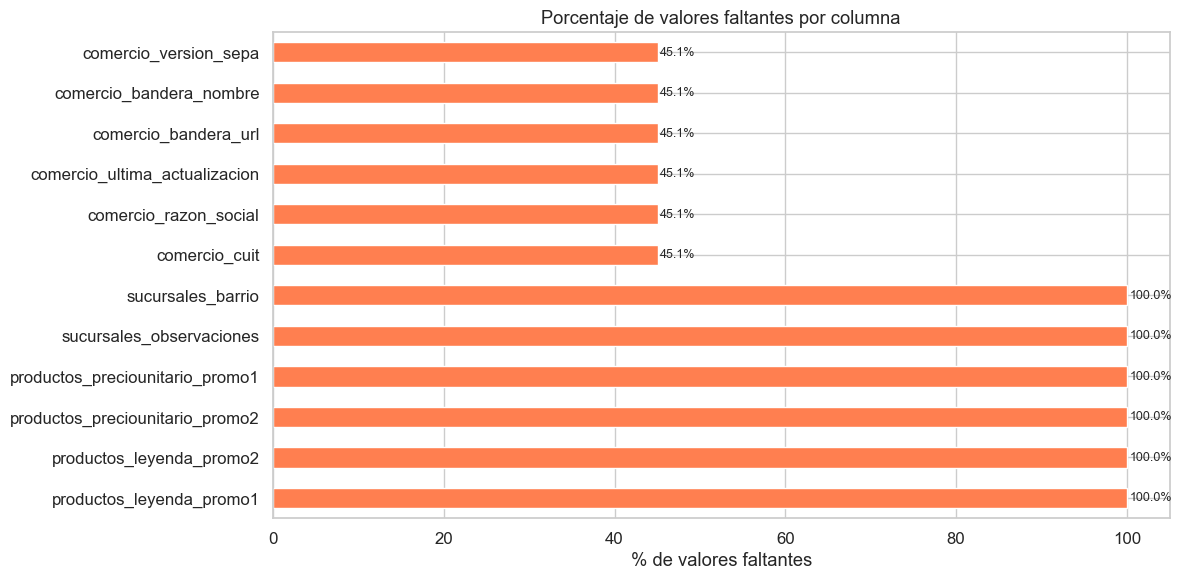

In [13]:
# Visualización de faltantes
if len(faltantes_filtrados) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(faltantes_filtrados) * 0.5)))
    faltantes_filtrados['pct_faltantes'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Porcentaje de valores faltantes por columna')
    for i, v in enumerate(faltantes_filtrados['pct_faltantes']):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron valores faltantes.')

### Análisis del tipo de faltantes

- **`productos_preciounitario_promo1/2` y `productos_leyenda_promo1/2`:** Estos campos son opcionales según la especificación SEPA. Son faltantes de tipo **MNAR** (Missing Not At Random): están vacíos porque el producto simplemente no tiene promoción vigente. El dato falta por la naturaleza misma de la variable.

- **`sucursales_barrio`:** Campo opcional en la especificación SEPA. Es un faltante de tipo **MNAR** (Missing Not At Random): No se ha informado practicamente ningún barrio.

- **`sucursales_observaciones`:** Campo opcional. Similar a barrio, es **MNAR**.

- **`sucursales_latitud/longitud`:** Vacíos en sucursales tipo "Web" (por definición). Esto es **MNAR** estructural.

In [14]:
# =============================================================================
# LIMPIEZA ESTRUCTURAL: ELIMINACIÓN INMEDIATA DE VARIABLES CONSTANTES
# =============================================================================
# Identificamos y removemos variables con un único valor (varianza cero) 
# para evitar que 'ensucien' los análisis y gráficos posteriores.
display(Markdown("#### ✂ Removemos variables con un único valor (varianza cero)"))
const_cols = [col for col in df.columns if df[col].nunique() <= 1]
if const_cols:
    print(f'Eliminando {len(const_cols)} variables constantes detectadas:')
    for col in const_cols: 
        print(f' • {col}')
    df.drop(columns=const_cols, inplace=True)
    print(f'\nDataset resultante: {df.shape}')
else:
    print('No se detectaron variables constantes.')


#### ✂ Removemos variables con un único valor (varianza cero)

Eliminando 18 variables constantes detectadas:
 • id_comercio
 • productos_preciounitario_promo1
 • productos_leyenda_promo1
 • productos_preciounitario_promo2
 • productos_leyenda_promo2
 • dia_1
 • dia_2
 • dia_3
 • dia_6
 • dia_7
 • sucursales_observaciones
 • sucursales_barrio
 • comercio_cuit
 • comercio_razon_social
 • comercio_bandera_nombre
 • comercio_bandera_url
 • comercio_ultima_actualizacion
 • comercio_version_sepa

Dataset resultante: (1426356, 31)


Luego de extraer las columnas con valores unicos, obtenenmos por comprobacion que ya no hay valores faltantes:

In [15]:
# Cantidad y porcentaje de faltantes por columna
faltantes = pd.DataFrame({
    'cant_faltantes': df.isnull().sum(),
    'pct_faltantes': (df.isnull().mean() * 100).round(2)
}).sort_values('pct_faltantes', ascending=False)

faltantes_filtrados = faltantes[faltantes['cant_faltantes'] > 0]
print(f'Columnas con faltantes: {len(faltantes_filtrados)} de {df.shape[1]}')
display(faltantes_filtrados)

Columnas con faltantes: 0 de 31


,cant_faltantes,pct_faltantes


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Variable target: `productos_precio_lista`

In [16]:
display(Markdown("#### 📏  Estadísticas del target"))

# Aseguramos tipo numérico
df['productos_precio_lista'] = pd.to_numeric(
    df['productos_precio_lista'], errors='coerce'
)

target = df['productos_precio_lista'].dropna()

print(f'  Media:    {target.mean():.2f}')
print(f'  Mediana:  {target.median():.2f}')
print(f'  Std:      {target.std():.2f}')
print(f'  Min:      {target.min():.2f}')
print(f'  Max:      {target.max():.2f}')
print(f'  Asimetría (Skewness): {target.skew():.2f}')
print(f'  Curtosis: {target.kurtosis():.2f}')
print(f'  Q1 (25%): {target.quantile(0.25):.2f}')
print(f'  Q3 (75%): {target.quantile(0.75):.2f}')
print(f'  IQR:      {target.quantile(0.75) - target.quantile(0.25):.2f}')

#### 📏  Estadísticas del target

  Media:    6578.59
  Mediana:  4050.00
  Std:      9913.97
  Min:      0.01
  Max:      596550.00
  Asimetría (Skewness): 14.37
  Curtosis: 520.10
  Q1 (25%): 2350.00
  Q3 (75%): 7250.00
  IQR:      4900.00


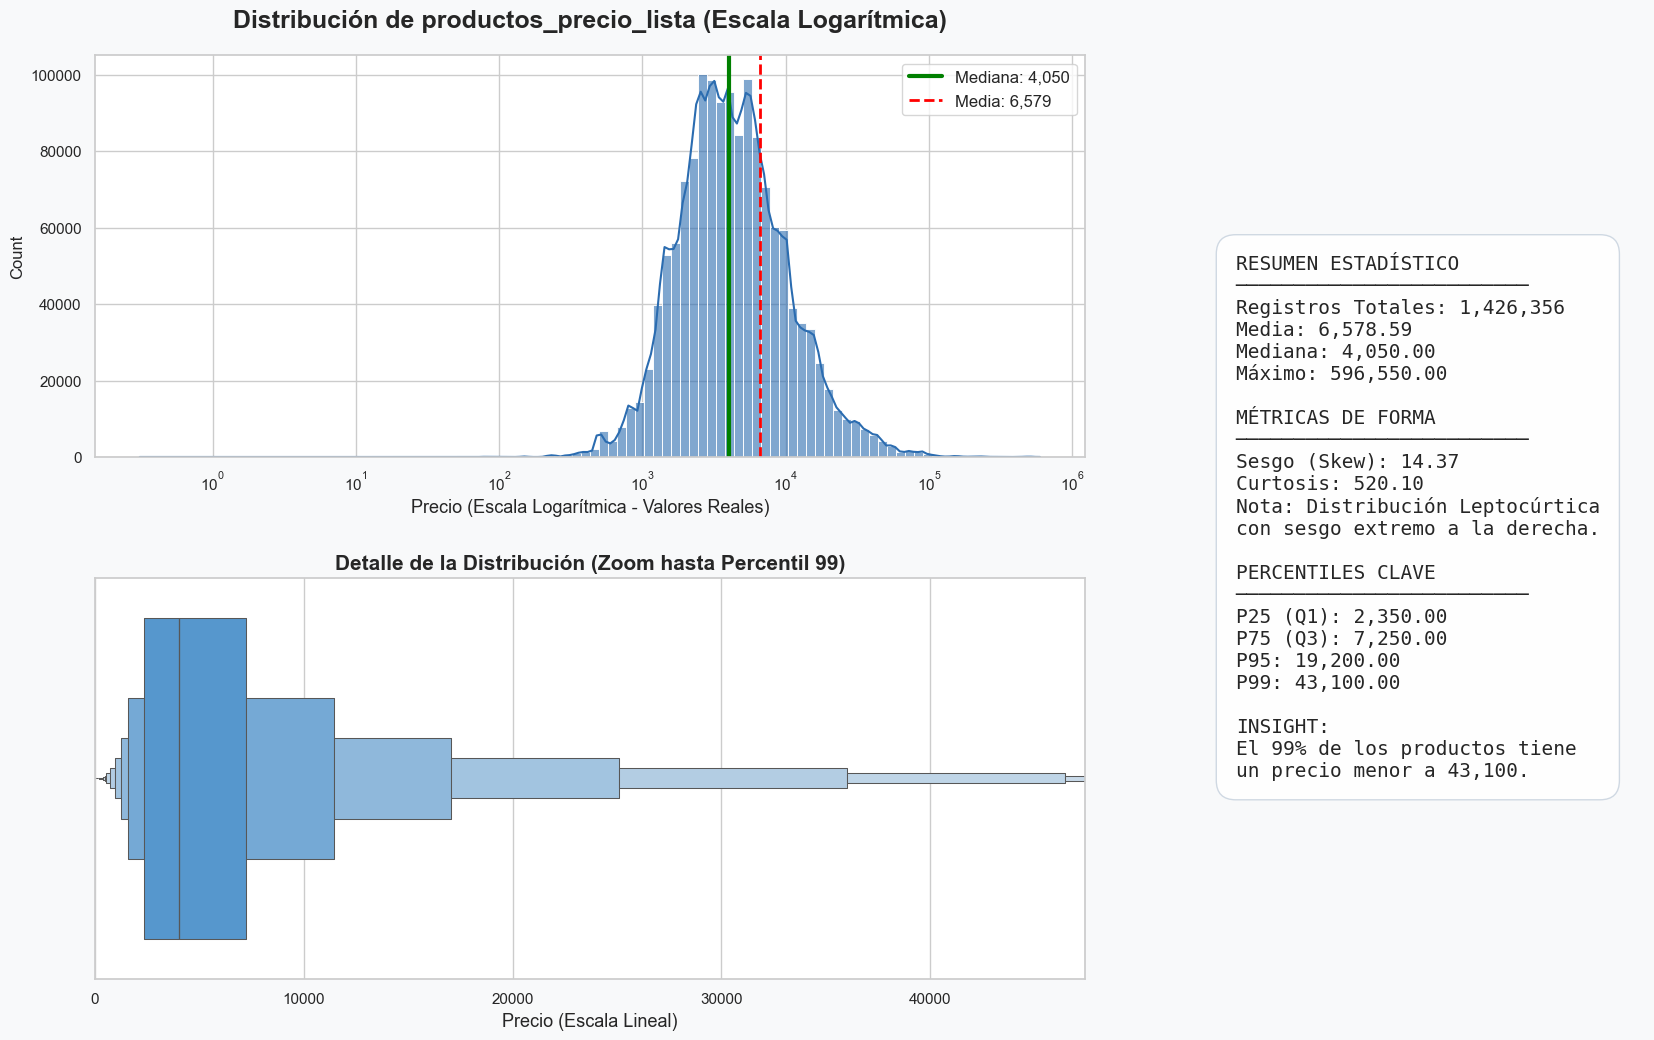

In [17]:
def plot_big_data_distribution(data, column_name):
    """
    Versión optimizada para +1.4M de registros con sesgo extremo.
    """
    # Limpieza de nulos y preparación de datos
    target = data[column_name].dropna()
    # Para el histograma logarítmico, evitamos valores <= 0 que causan error matemático
    target_positive = target[target > 0.1] 
    
    # Configuración de estilo
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 12), facecolor='#f8f9fa')
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # --- 1. HISTOGRAMA CON ESCALA LOGARÍTMICA ---
    # Esto permite ver la forma de la distribución sin que el sesgo la aplaste
    ax1 = fig.add_subplot(gs[0, :2])
    sns.histplot(target_positive, bins=100, log_scale=True, kde=True, 
                 color='#2b6cb0', alpha=0.6, edgecolor='white', ax=ax1)
    
    median_val = target.median()
    mean_val = target.mean()
    ax1.axvline(median_val, color='green', lw=3, label=f'Mediana: {median_val:,.0f}')
    ax1.axvline(mean_val, color='red', linestyle='--', lw=2, label=f'Media: {mean_val:,.0f}')
    
    ax1.set_title(f'Distribución de {column_name} (Escala Logarítmica)', fontsize=18, fontweight='bold', pad=20)
    ax1.set_xlabel('Precio (Escala Logarítmica - Valores Reales)', fontsize=13)
    ax1.legend(fontsize=12)

    # --- 2. BOXENPLOT (EL REEMPLAZO DEL BOXPLOT PARA BIG DATA) ---
    # El Boxenplot muestra niveles de cuantiles sucesivos, ideal para 1.4M de filas
    ax2 = fig.add_subplot(gs[1, :2])
    sns.boxenplot(x=target, ax=ax2, color='#4299e1', showfliers=False) 
    
    # Hacemos zoom hasta el Percentil 99 para que la "caja" sea el protagonista
    p99 = target.quantile(0.99)
    ax2.set_xlim(-target.min(), p99 * 1.1) 
    ax2.set_title(f'Detalle de la Distribución (Zoom hasta Percentil 99)', fontsize=15, fontweight='semibold')
    ax2.set_xlabel('Precio (Escala Lineal)', fontsize=13)

    # --- 3. PANEL DE ESTADÍSTICAS (KPIs) ---
    ax3 = fig.add_subplot(gs[:, 2])
    ax3.axis('off')
    
    stats_text = (
        f"RESUMEN ESTADÍSTICO\n"
        f"{'─'*25}\n"
        f"Registros Totales: {len(target):,}\n"
        f"Media: {mean_val:,.2f}\n"
        f"Mediana: {median_val:,.2f}\n"
        f"Máximo: {target.max():,.2f}\n\n"
        f"MÉTRICAS DE FORMA\n"
        f"{'─'*25}\n"
        f"Sesgo (Skew): {target.skew():.2f}\n"
        f"Curtosis: {target.kurtosis():.2f}\n"
        f"Nota: Distribución Leptocúrtica\n"
        f"con sesgo extremo a la derecha.\n\n"
        f"PERCENTILES CLAVE\n"
        f"{'─'*25}\n"
        f"P25 (Q1): {target.quantile(0.25):,.2f}\n"
        f"P75 (Q3): {target.quantile(0.75):,.2f}\n"
        f"P95: {target.quantile(0.95):,.2f}\n"
        f"P99: {p99:,.2f}\n\n"
        f"INSIGHT:\n"
        f"El 99% de los productos tiene\n"
        f"un precio menor a {p99:,.0f}."
    )
    
    ax3.text(0.05, 0.5, stats_text, fontsize=14, family='monospace', va='center',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cbd5e0', boxstyle='round,pad=1'))

    plt.show()

plot_big_data_distribution(df, 'productos_precio_lista')

### Observaciones sobre el target

La distribución del precio de lista es fuertemente asimétrica a la derecha (skewness alto),
con una cola pesada de productos de alto valor. El log-transform la normaliza considerablemente.
Se observan outliers en la cola superior (productos de lujo o errores).

### 3.2 Análisis de variables categóricas clave

In [18]:
display(Markdown("#### ✨ Variables categóricas relevantes"))
cat_cols = ['sucursales_tipo', 'provincia_nombre', 'productos_marca',
            'productos_unidad_medida_presentacion', 'comercio_bandera_nombre']

for col in cat_cols:
    if col in df.columns:
        n_unique = df[col].nunique()
        print(f'\n{col}: {n_unique} valores únicos')
        print(df[col].value_counts().head(10))

#### ✨ Variables categóricas relevantes


sucursales_tipo: 2 valores únicos
sucursales_tipo
Supermercado    1196525
Hipermercado     229831
Name: count, dtype: int64

provincia_nombre: 19 valores únicos
provincia_nombre
Buenos Aires    407060
CABA            254446
Córdoba         222593
Mendoza         196511
Tucumán          65023
Salta            59394
San Juan         44334
Entre Ríos       20330
Catamarca        20295
Chubut           18835
Name: count, dtype: int64

productos_marca: 1505 valores únicos
productos_marca
SIN MARCA        31064
DOVE             13594
ARCOR            13408
LA SERENISIMA    13271
LA CAMPAGNOLA    13252
NIVEA            12797
ALICANTE         11900
PROCENEX         11860
DOS ANCLAS       11824
LA VIRGINIA      10981
Name: count, dtype: int64

productos_unidad_medida_presentacion: 13 valores únicos
productos_unidad_medida_presentacion
gr.    741390
ml.    454447
un.    141644
cc.     35719
Kg      26941
lt.     18838
m2       3532
KG       1361
par       743
Pie       597
Name: count, dtype: i

#### 🛒 Distribución por tipo de sucursal

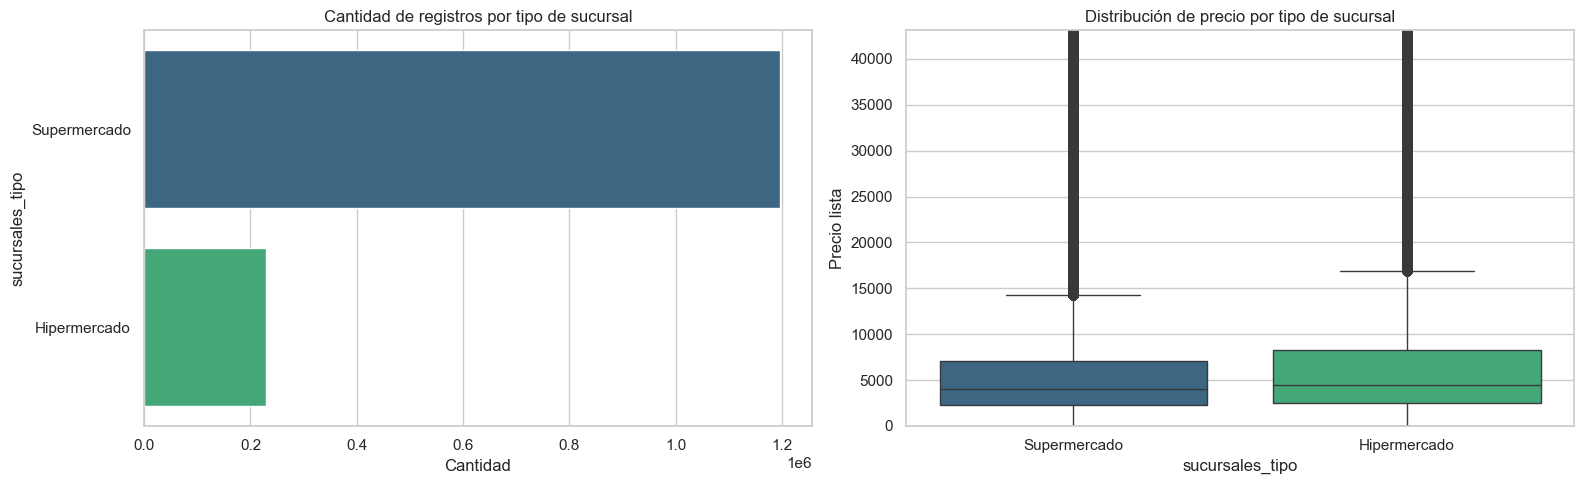

In [19]:
display(Markdown("#### 🛒 Distribución por tipo de sucursal"))
if 'sucursales_tipo' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Conteo por tipo
    order = df['sucursales_tipo'].value_counts().index
    sns.countplot(data=df, y='sucursales_tipo', order=order, ax=axes[0],
                  hue='sucursales_tipo', legend=False, palette='viridis')
    axes[0].set_title('Cantidad de registros por tipo de sucursal')
    axes[0].set_xlabel('Cantidad')
    
    # Precio por tipo de sucursal
    sns.boxplot(data=df, x='sucursales_tipo', y='productos_precio_lista',
                order=order, ax=axes[1], hue='sucursales_tipo', legend=False,
                palette='viridis')
    axes[1].set_title('Distribución de precio por tipo de sucursal')
    axes[1].set_ylabel('Precio lista')
    # Limitar eje Y para visualización
    q99 = target.quantile(0.99)
    axes[1].set_ylim(0, q99)
    
    plt.tight_layout()
    plt.show()

####  🇦🇷 Distribución por provincia

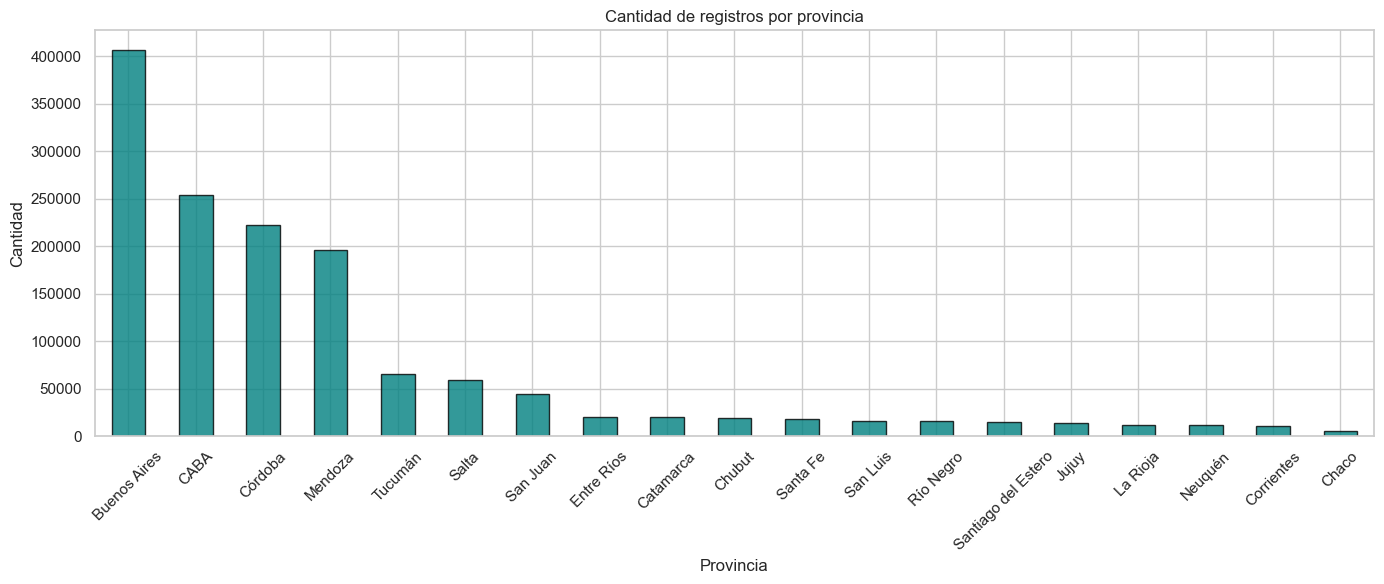

In [20]:
display(Markdown("####  🇦🇷 Distribución por provincia"))
if 'provincia_nombre' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    prov_counts = df['provincia_nombre'].value_counts()
    prov_counts.plot(kind='bar', ax=ax, color='teal', edgecolor='black', alpha=0.8)
    ax.set_title('Cantidad de registros por provincia')
    ax.set_xlabel('Provincia')
    ax.set_ylabel('Cantidad')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### 🥇 Top 20 marcas más frecuentes y su precio promedio

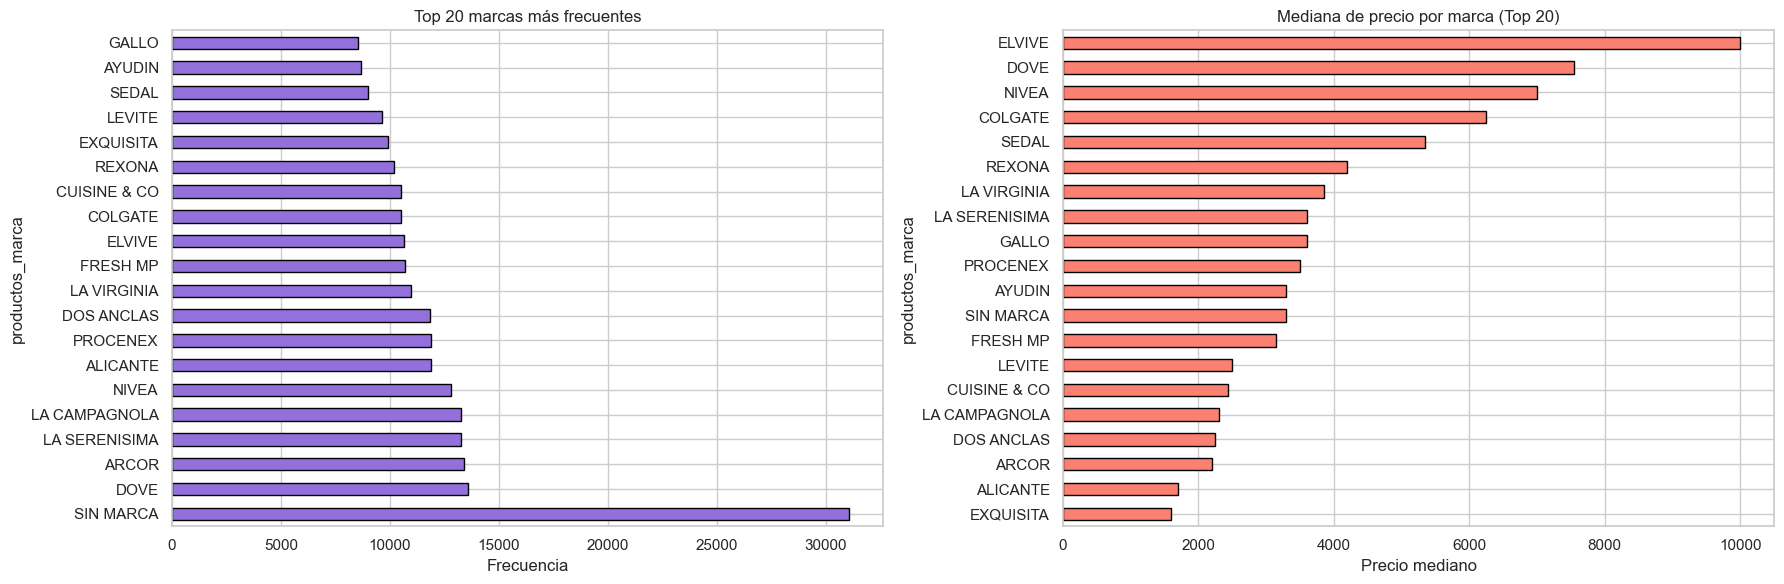

In [21]:
display(Markdown("#### 🥇 Top 20 marcas más frecuentes y su precio promedio"))
if 'productos_marca' in df.columns:
    top_marcas = df['productos_marca'].value_counts().head(20).index
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Frecuencia de marcas
    df[df['productos_marca'].isin(top_marcas)]['productos_marca'].value_counts().plot(
        kind='barh', ax=axes[0], color='mediumpurple', edgecolor='black'
    )
    axes[0].set_title('Top 20 marcas más frecuentes')
    axes[0].set_xlabel('Frecuencia')
    
    # Precio medio por marca
    precio_marca = df[df['productos_marca'].isin(top_marcas)].groupby(
        'productos_marca')['productos_precio_lista'].median().sort_values(ascending=True)
    precio_marca.plot(kind='barh', ax=axes[1], color='salmon', edgecolor='black')
    axes[1].set_title('Mediana de precio por marca (Top 20)')
    axes[1].set_xlabel('Precio mediano')
    
    plt.tight_layout()
    plt.show()

### 3.3 Análisis de variables numéricas

In [22]:
# Variables numéricas potencialmente útiles
display(Markdown("#### 🎰 Variables numéricas potencialmente útiles"))
num_cols = ['productos_precio_lista', 'productos_cantidad_presentacion', 
            'productos_cantidad_referencia', 'sucursales_latitud', 
            'sucursales_longitud']

# 1. Intentamos convertir TODAS las columnas del dataframe a números de forma segura.
for col in df.columns:
    try:
        # Forzar la conversión y aplicar el cambio.
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        # Si arroja un error porque tiene puro texto, no hacemos nada y sigue siendo texto.
        pass

# 2. Calculamos estadísticas
#desc = df.describe(include='all')
desc = df[num_cols].describe()

# 3. Función inteligente para formatear
def quitar_ceros_basura(val):
    if pd.isna(val): 
        return "NaN"
    # Usamos type() para asegurar fuertemente que no confunda booleanos
    if type(val) in [int, float]:
        texto = f"{val:,.3f}"
        if '.' in texto:
            texto = texto.rstrip('0').rstrip('.')
        return texto
    return str(val)

# 4. Aplicamos a toda la tabla
desc_formateado = desc.copy()
for col in desc.columns:
    desc_formateado[col] = desc[col].apply(quitar_ceros_basura)

display(Markdown(f"```\n{desc_formateado.to_string()}\n```"))

#### 🎰 Variables numéricas potencialmente útiles

```
      productos_precio_lista productos_cantidad_presentacion productos_cantidad_referencia sucursales_latitud sucursales_longitud
count              1,426,356                       1,426,356                     1,426,356          1,426,356           1,426,356
mean               6,578.588                         144.698                        51.061            -33.102             -62.392
std                9,913.965                         250.164                        49.497               3.46               4.141
min                     0.01                            0.01                             1            -45.873             -69.592
25%                    2,350                             0.5                             1            -34.628             -65.414
50%                    4,050                               3                           100            -34.401             -62.105
75%                    7,250                             190                           100            -31.433             -58.448
max                  596,550                           4,500                           100            -23.131             -56.684
```

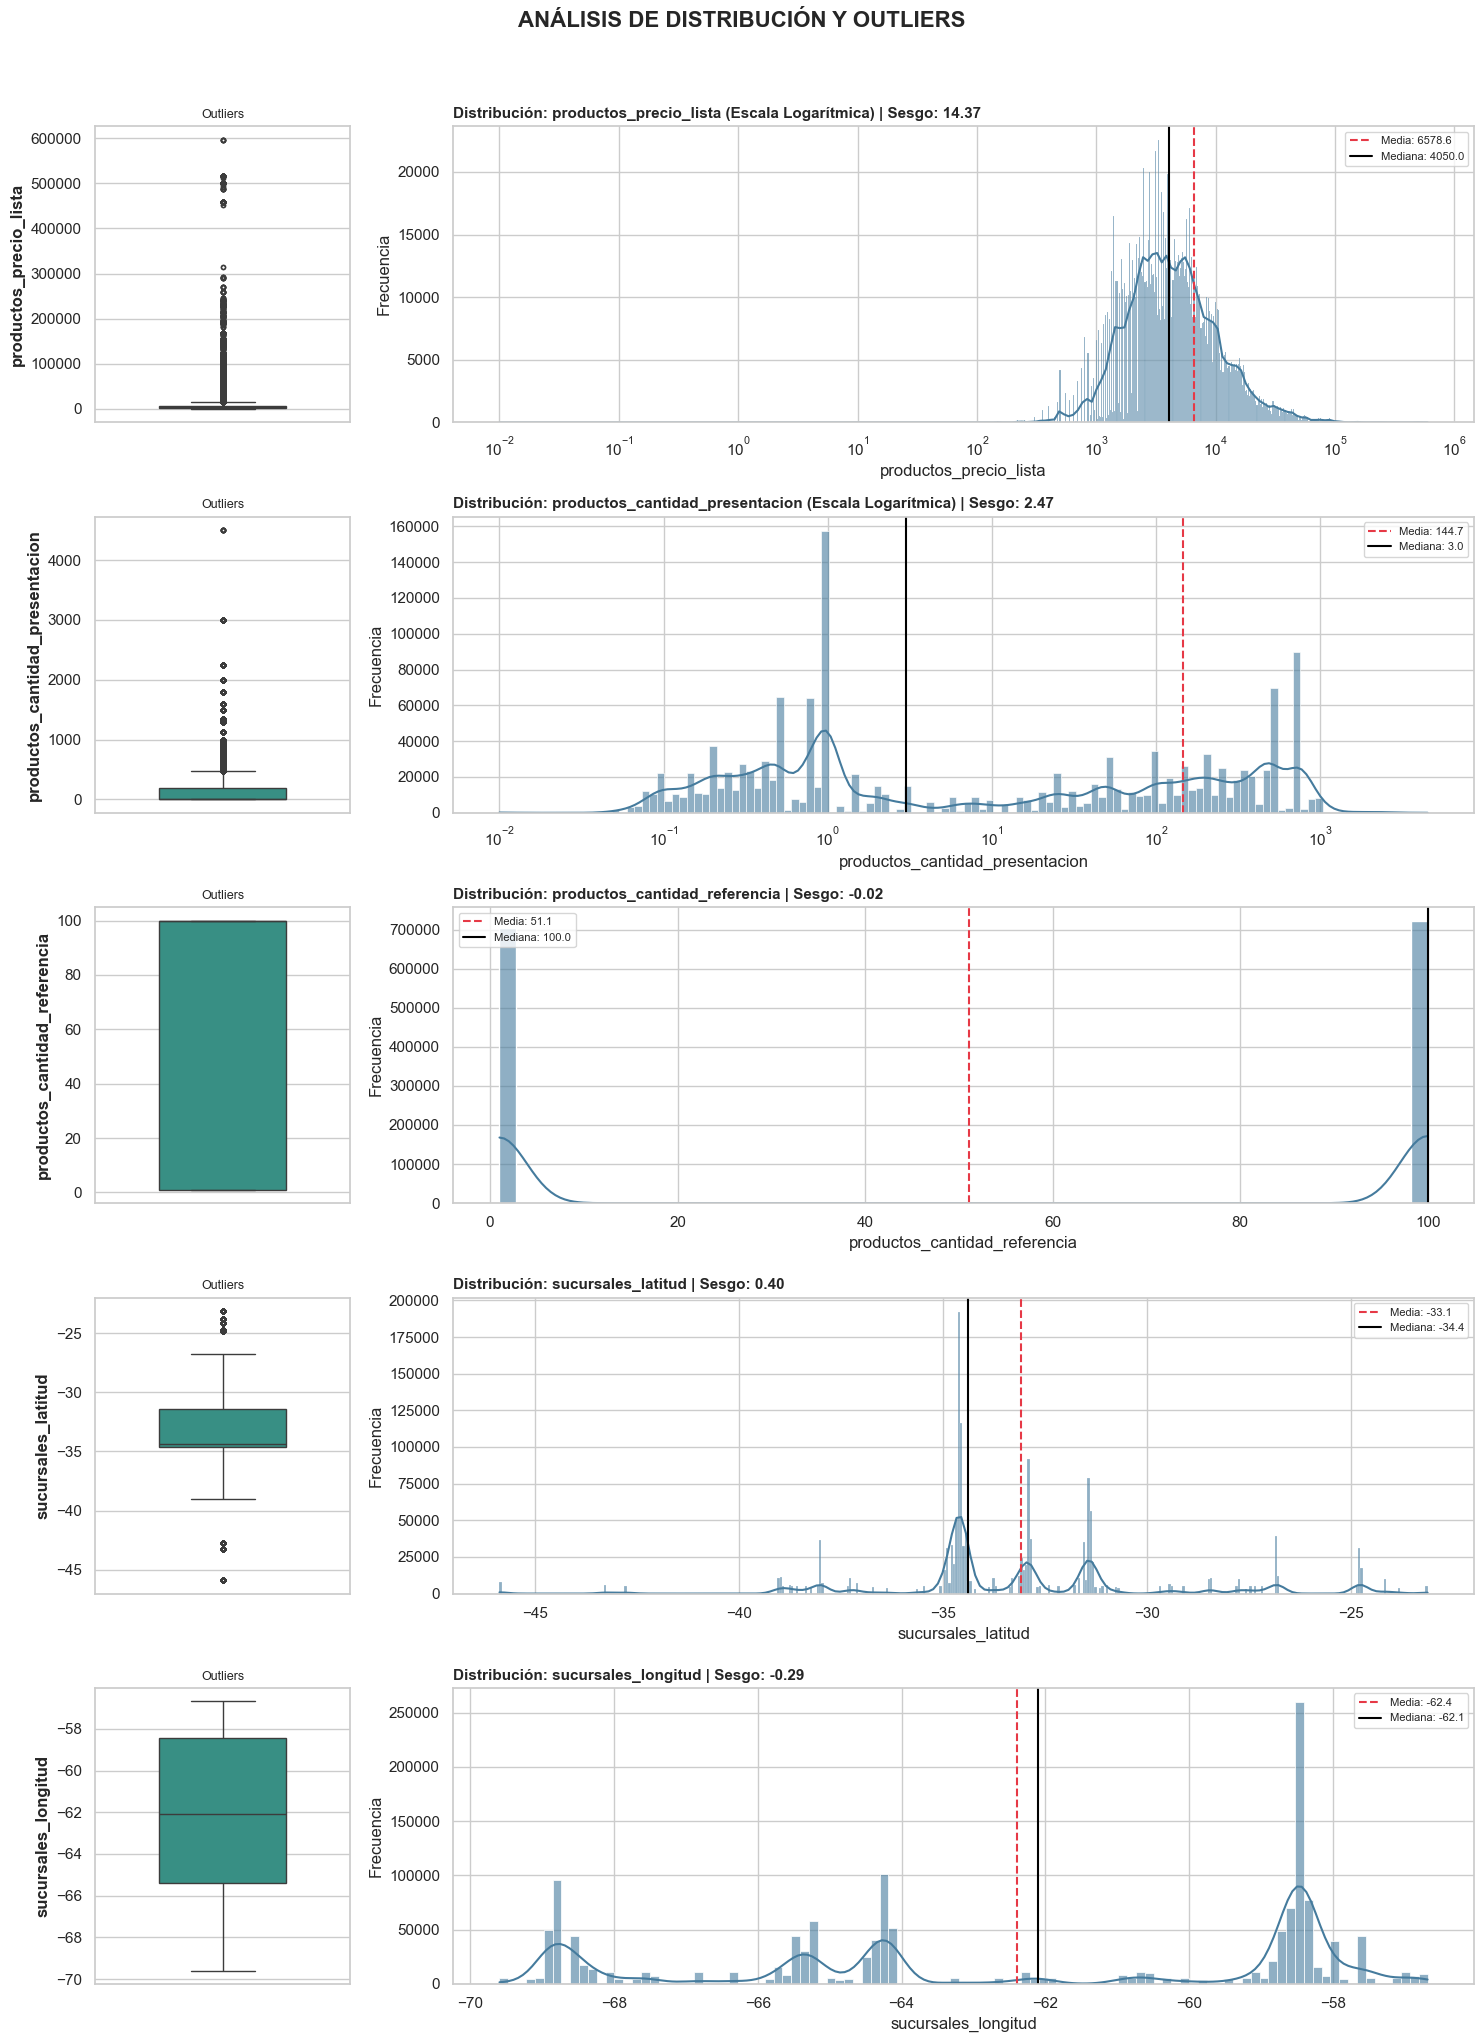

In [23]:
# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
_BLUE, _RED, _GREEN = "#457B9D", "#E63946", "#2A9D8F"

# 2. Definir dimensiones
n_vars = len(num_cols)
fig, axes = plt.subplots(n_vars, 2, figsize=(15, 4 * n_vars), 
                         gridspec_kw={'width_ratios': [1, 4]})
fig.suptitle('ANÁLISIS DE DISTRIBUCIÓN Y OUTLIERS', fontsize=16, fontweight='bold', y=1.02)

# Si solo hay una variable, axes no es una matriz, lo convertimos para el bucle
if n_vars == 1: axes = np.array([axes])

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    if data.empty: continue
    
    # Métricas
    s_val = skew(data)
    # Solo aplicamos log si el sesgo es alto Y todos los valores son positivos > 0
    use_log = (abs(s_val) > 2) and (data > 0).all()
    
    # --- A. BOXPLOT (Eje izquierdo) ---
    sns.boxplot(y=data, ax=axes[i, 0], color=_GREEN, width=0.5, fliersize=3)
    axes[i, 0].set_title(f'Outliers', fontsize=9)
    axes[i, 0].set_ylabel(col, fontweight='bold')

    # --- B. HISTOGRAMA (Eje derecho) ---
    # Fix para el error: usamos 10 si es True, sino False
    log_param = 10 if use_log else False
    
    sns.histplot(data, kde=True, ax=axes[i, 1], color=_BLUE, 
                 log_scale=log_param, alpha=0.6, edgecolor='white')
    
    # Líneas estadísticas
    m_val, med_val = data.mean(), data.median()
    axes[i, 1].axvline(m_val, color=_RED, linestyle='--', label=f'Media: {m_val:.1f}')
    axes[i, 1].axvline(med_val, color='black', linestyle='-', label=f'Mediana: {med_val:.1f}')
    
    # Estética del histograma
    title_suffix = " (Escala Logarítmica)" if use_log else ""
    axes[i, 1].set_title(f"Distribución: {col}{title_suffix} | Sesgo: {s_val:.2f}", 
                         loc='left', fontsize=11, fontweight='bold')
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

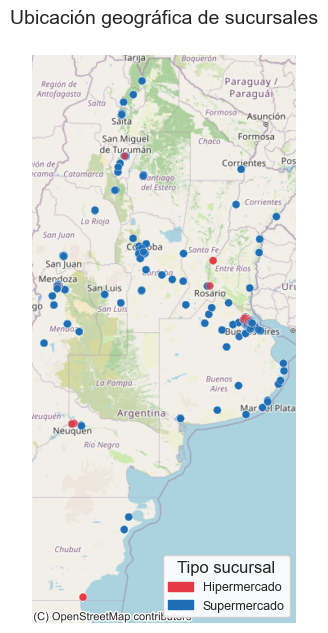

In [24]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if 'sucursales_latitud' in df.columns and 'sucursales_longitud' in df.columns:
    geo = df[['sucursales_latitud', 'sucursales_longitud', 'sucursales_tipo']].dropna()

    gdf = gpd.GeoDataFrame(
        geo,
        geometry=gpd.points_from_xy(geo['sucursales_longitud'], geo['sucursales_latitud']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    # 🎨 Colores explícitos: rojo y azul
    color_dict = {
        tipo: color
        for tipo, color in zip(
            sorted(gdf['sucursales_tipo'].unique()),
            ['#e63946', '#1d6eb5']   # rojo, azul — ajustá si hay más de 2 tipos
        )
    }
    colors = gdf['sucursales_tipo'].map(color_dict)

    # 📐 Relación de aspecto correcta
    bounds = gdf.total_bounds  # [minx, miny, maxx, maxy] en metros
    width  = bounds[2] - bounds[0]
    height = bounds[3] - bounds[1]
    aspect = height / width

    fig_w = 3
    fig_h = fig_w * aspect   # altura proporcional al extent real
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        c=colors,
        alpha=0.75, s=30, zorder=5, linewidths=0.2, edgecolors='white'
    )

    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )

    ax.set_axis_off()
    ax.set_title('Ubicación geográfica de sucursales', fontsize=14, pad=12)

    # Leyenda con colores explícitos
    handles = [
        mpatches.Patch(color=c, label=t)
        for t, c in color_dict.items()
    ]
    ax.legend(handles=handles, title='Tipo sucursal', loc='lower right',
              framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.show()

---
## 4. Identificación y tratamiento de errores, outliers e inconsistencias

### 4.1 Detección de errores e inconsistencias

In [25]:
# Precios no positivos (errores evidentes)
display(Markdown("#### 💸 Precios y cantidades con errores evidentes"))
n_precio_cero = (df['productos_precio_lista'] <= 49).sum()
n_precio_null = df['productos_precio_lista'].isnull().sum()
print(f'Precios <= 49: {n_precio_cero} ({n_precio_cero/len(df)*100:.2f}%)')
print(f'Precios nulos: {n_precio_null} ({n_precio_null/len(df)*100:.2f}%)')

# Productos con cantidad de presentación no positiva
if 'productos_cantidad_presentacion' in df.columns:
    n_cant_cero = (df['productos_cantidad_presentacion'] <= 0).sum()
    print(f'Cantidad presentación <= 0: {n_cant_cero}')

#### 💸 Precios y cantidades con errores evidentes

Precios <= 49: 17 (0.00%)
Precios nulos: 0 (0.00%)
Cantidad presentación <= 0: 0


In [26]:
# Revision de errores
display(Markdown("#### 👀 Revision de errores 🥤"))
columnas_a_mostrar = [
    'productos_descripcion', 
    'productos_precio_lista', 
]
display(df.loc[df['productos_precio_lista'] <= 49, columnas_a_mostrar])

#### 👀 Revision de errores 🥤

,productos_descripcion,productos_precio_lista
0,Botella coca cola PVC-1.5-lt.,0.31
1,botella coca cola x 2 lt. PVC-2-lt.,1.19
2,botella coca cola x 2 lt. PVC-2-lt.,1.19
3,botella coca cola x 2 lt. PVC-2-lt.,1.19
4,botella coca cola x 2 lt. PVC-2-lt.,1.19
5,botella coca cola x 2 lt. PVC-2-lt.,1.25
6,botella coca cola x 2 lt. PVC-2-lt.,1.19
7,botella coca cola x 2 lt. PVC-2-lt.,1.19
8,botella coca cola x 2 lt. PVC-2-lt.,1.19
9,botella coca cola x 2 lt. PVC-2-lt.,1.19


In [27]:
# Eliminamos registros con precio <= 0 o nulo (son errores de carga)
display(Markdown("#### ❌ Eliminamos registros con presuntos errores de carga"))
mask_valid = (df['productos_precio_lista'] > 10) & (df['productos_precio_lista'].notna())
df_clean = df[mask_valid].copy()
print(f'Registros luego de limpiar precios inválidos: {len(df_clean):,} (eliminados: {len(df) - len(df_clean):,})')

#### ❌ Eliminamos registros con presuntos errores de carga

Registros luego de limpiar precios inválidos: 1,426,339 (eliminados: 17)


### 4.2 Detección de outliers (IQR y Z-score)

In [28]:
# Método IQR para el target
display(Markdown("#### ✏ Método IQR para el target"))
Q1 = df_clean['productos_precio_lista'].quantile(0.25)
Q3 = df_clean['productos_precio_lista'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

n_outliers_iqr = ((df_clean['productos_precio_lista'] < lower) | 
                  (df_clean['productos_precio_lista'] > upper)).sum()
print(f'Outliers IQR en precio_lista: {n_outliers_iqr} ({n_outliers_iqr/len(df_clean)*100:.2f}%)')
print(f'Rango aceptable IQR: [{lower:.2f}, {upper:.2f}]')

#### ✏ Método IQR para el target

Outliers IQR en precio_lista: 122260 (8.57%)
Rango aceptable IQR: [-5000.00, 14600.00]


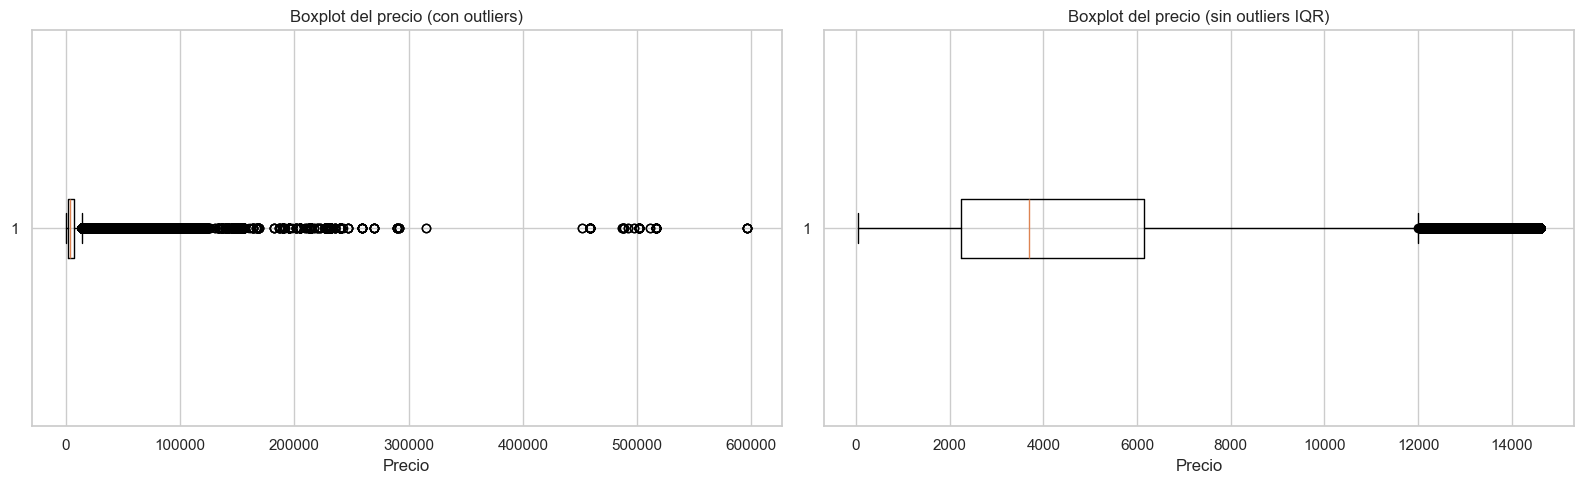

In [29]:
# Visualización de outliers con boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot original
axes[0].boxplot(df_clean['productos_precio_lista'].dropna(), vert=False)
axes[0].set_title('Boxplot del precio (con outliers)')
axes[0].set_xlabel('Precio')

# Boxplot sin outliers extremos
precio_sin_outliers = df_clean.loc[
    (df_clean['productos_precio_lista'] >= lower) & 
    (df_clean['productos_precio_lista'] <= upper),
    'productos_precio_lista'
]
axes[1].boxplot(precio_sin_outliers, vert=False)
axes[1].set_title('Boxplot del precio (sin outliers IQR)')
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()

In [30]:
# Tratamiento de outliers: capping (winsorización) en los percentiles 1 y 99
display(Markdown("#### ✂ Tratamiento de outliers y winsorización"))
p01 = df_clean['productos_precio_lista'].quantile(0.01)
p99 = df_clean['productos_precio_lista'].quantile(0.99)

df_clean['productos_precio_lista'] = df_clean['productos_precio_lista'].clip(lower=p01, upper=p99)

print(f'Precio capped a [{p01:.2f}, {p99:.2f}]')
print(f'Nueva media: {df_clean["productos_precio_lista"].mean():.2f}')
print(f'Nueva mediana: {df_clean["productos_precio_lista"].median():.2f}')

#### ✂ Tratamiento de outliers y winsorización

Precio capped a [650.00, 43100.00]
Nueva media: 6311.46
Nueva mediana: 4050.00


---
## 5. Definición del problema de ML supervisado

### Problema: Regresión

**Objetivo:** Predecir el precio de lista (`productos_precio_lista`) de un producto en una sucursal dada, utilizando features como:
- Ubicación geográfica (latitud, longitud)
- Tipo de sucursal (Supermercado, Hipermercado, Autoservicio, etc.)
- Provincia
- Marca del producto
- Unidad de medida y cantidad de presentación
- Si el producto tiene código EAN o es interno

**Variable target:** `productos_precio_lista` (continua)

---

## 6. Preprocesamiento y limpieza del dataset

### 6.1 Selección de columnas relevantes

In [31]:
# Seleccionamos las columnas relevantes para el modelo
display(Markdown("#### 💎 Columnas relevantes para el modelo"))
cols_features = [
    'sucursales_tipo',
    'provincia_nombre',
    'sucursales_latitud',
    'sucursales_longitud',
    'productos_cantidad_presentacion',
    'productos_unidad_medida_presentacion',
    'productos_marca',
    'productos_cantidad_referencia',
    'productos_unidad_medida_referencia'
]

target_col = 'productos_precio_lista'

# Filtrar solo columnas que existen
cols_features = [c for c in cols_features if c in df_clean.columns]

df_model = df_clean[cols_features + [target_col]].copy()
print(f'Dataset para modelado: {df_model.shape}')
display(df_model.head())

#### 💎 Columnas relevantes para el modelo

Dataset para modelado: (1426339, 10)


,sucursales_tipo,provincia_nombre,sucursales_latitud,sucursales_longitud,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_lista
17,Supermercado,San Juan,-31.5172,-68.5259,1.0,Kg,CAGNOLI,1,Kg,37750.0
18,Supermercado,Chubut,-42.7683,-65.0390,1.0,Kg,CAGNOLI,1,Kg,41480.0
19,Supermercado,Río Negro,-39.0451,-67.5778,1.0,Kg,CAGNOLI,1,Kg,37750.0
20,Hipermercado,Buenos Aires,-38.0126,-57.5652,1.0,Kg,CAGNOLI,1,Kg,41480.0
21,Supermercado,CABA,-34.5609,-58.4520,1.0,Kg,CAGNOLI,1,Kg,41480.0


In [32]:
# Conversiones de tipo
display(Markdown("#### 🖇 Conversiones de tipo"))
df_model['sucursales_latitud'] = pd.to_numeric(df_model['sucursales_latitud'], errors='coerce')
df_model['sucursales_longitud'] = pd.to_numeric(df_model['sucursales_longitud'], errors='coerce')
df_model['productos_cantidad_presentacion'] = pd.to_numeric(
    df_model['productos_cantidad_presentacion'], errors='coerce'
)

df_model.dtypes

#### 🖇 Conversiones de tipo

sucursales_tipo                          object
provincia_nombre                         object
sucursales_latitud                      float64
sucursales_longitud                     float64
productos_cantidad_presentacion         float64
productos_unidad_medida_presentacion     object
productos_marca                          object
productos_cantidad_referencia             int64
productos_unidad_medida_referencia       object
productos_precio_lista                  float64
dtype: object

### 6.2 Tratamiento de faltantes

In [33]:
# Faltantes antes del tratamiento
display(Markdown("#### 🔍 Faltantes antes del tratamiento"))
print('=== Faltantes antes ===')
print(df_model.isnull().sum())
print(f'\nTotal filas: {len(df_model):,}')

#### 🔍 Faltantes antes del tratamiento

=== Faltantes antes ===
sucursales_tipo                         0
provincia_nombre                        0
sucursales_latitud                      0
sucursales_longitud                     0
productos_cantidad_presentacion         0
productos_unidad_medida_presentacion    0
productos_marca                         0
productos_cantidad_referencia           0
productos_unidad_medida_referencia      0
productos_precio_lista                  0
dtype: int64

Total filas: 1,426,339


#### Estrategias de imputación concideradas pero no utilizadas por no ser necesarias:
   - Latitud/Longitud: imputar con la mediana por provincia (MAR: depende de la provincia)
   - sucursales_tipo: imputar con moda
   - productos_marca: imputar con 'DESCONOCIDA'
   - productos_unidad_medida_presentacion: imputar con moda
   - productos_cantidad_presentacion: imputar con mediana

```python
# Eliminar filas donde el target es nulo
df_model = df_model.dropna(subset=[target_col])

# Imputar Latitud/Longitud con mediana por provincia
for coord in ['sucursales_latitud', 'sucursales_longitud']:
    if coord in df_model.columns:
        mediana_prov = df_model.groupby('provincia_nombre')[coord].transform('median')
        df_model[coord] = df_model[coord].fillna(mediana_prov)
        # Si aún quedan nulos (provincia sin datos), usar mediana global
        df_model[coord] = df_model[coord].fillna(df_model[coord].median())

# Imputar categóricas con moda
for col in ['sucursales_tipo', 'productos_unidad_medida_presentacion']:
    if col in df_model.columns:
        moda = df_model[col].mode()[0]
        df_model[col] = df_model[col].fillna(moda)

# Imputar marca con 'DESCONOCIDA'
if 'productos_marca' in df_model.columns:
    df_model['productos_marca'] = df_model['productos_marca'].fillna('DESCONOCIDA')

# Imputar cantidad presentación con mediana
if 'productos_cantidad_presentacion' in df_model.columns:
    df_model['productos_cantidad_presentacion'] = df_model['productos_cantidad_presentacion'].fillna(
        df_model['productos_cantidad_presentacion'].median()
    )

# Provincia: rellenar con 'DESCONOCIDA' si falta
if 'provincia_nombre' in df_model.columns:
    df_model['provincia_nombre'] = df_model['provincia_nombre'].fillna('DESCONOCIDA')

print('=== Faltantes después ===')
print(df_model.isnull().sum())

# Eliminar filas que aún tengan faltantes
df_model = df_model.dropna()
print(f'\nDataset final limpio: {df_model.shape}')
```

### 6.3 Split train / test

Realizamos el split **antes** de aplicar transformaciones que dependen de estadísticos
(como escalado, codificación por frecuencia, etc.) para evitar **data leakage**.

In [34]:
# Split train / test
display(Markdown("#### 💔 Split antes de aplicar transformaciones"))
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: X={X_train.shape}, y={y_train.shape}')
print(f'Test:  X={X_test.shape}, y={y_test.shape}')

#### 💔 Split antes de aplicar transformaciones

Train: X=(1141071, 9), y=(1141071,)
Test:  X=(285268, 9), y=(285268,)


---
## 7. Feature Engineering

### 7.1 Creación de nuevos features

In [35]:
# Creación de nuevos features
display(Markdown("#### ⚙ Creación de features"))
def crear_features(df):
    """Crea features adicionales a partir de los datos existentes."""
    df = df.copy()
    
    # 1. Log de cantidad de presentación (reduce asimetría)
    if 'productos_cantidad_presentacion' in df.columns:
        df['log_cantidad_presentacion'] = np.log1p(
            df['productos_cantidad_presentacion'].clip(lower=0)
        )
    
    # 2. Indicador de producto con EAN (estándar) vs código interno
    #if 'productos_ean' in df.columns:
    #    df['es_ean'] = (df['productos_ean'] == 1).astype(int)
    
    # 3. Frecuencia de la marca (proxy de popularidad/tamaño)
    #    Se calcula solo en train para evitar data leakage
    #    (se aplicará después del split)
    
    return df

X_train = crear_features(X_train)
X_test = crear_features(X_test)

print('Features creados:')
print(X_train.columns.tolist())

#### ⚙ Creación de features

Features creados:
['sucursales_tipo', 'provincia_nombre', 'sucursales_latitud', 'sucursales_longitud', 'productos_cantidad_presentacion', 'productos_unidad_medida_presentacion', 'productos_marca', 'productos_cantidad_referencia', 'productos_unidad_medida_referencia', 'log_cantidad_presentacion']


In [36]:
# Frequency Encoding para 'productos_marca' (calculado solo en train)
display(Markdown("#### 🗜 Frequency Encoding para 'productos_marca' solo en _train_"))
if 'productos_marca' in X_train.columns:
    freq_marca = X_train['productos_marca'].value_counts(normalize=True)
    X_train['marca_freq'] = X_train['productos_marca'].map(freq_marca)
    X_test['marca_freq'] = X_test['productos_marca'].map(freq_marca)
    # Marcas no vistas en train → frecuencia 0
    X_test['marca_freq'] = X_test['marca_freq'].fillna(0)
    
    print(f'Frequency encoding de marca (ejemplo):')
    display(X_train[['productos_marca', 'marca_freq']].head(10))

#### 🗜 Frequency Encoding para 'productos_marca' solo en _train_

Frequency encoding de marca (ejemplo):


,productos_marca,marca_freq
1088455,NATUZEN,0.000380
359838,TAMBO,0.000038
1245053,MOLÉ,0.001034
1162483,GUM,0.002611
569002,DONCELLA,0.001755
18389,LA PAULINA,0.004453
271076,LA SALTEÑA,0.002975
1027594,WHISKAS,0.004147
403574,LA PAULINA,0.004453
484885,LA CAMPAGNOLA,0.009278


### 7.2 Codificación de variables categóricas

In [37]:
# --- Ordinal Encoding para sucursales_tipo (tiene orden natural) ---
display(Markdown("#### 🆔 Codificación de categóricas"))
tipo_orden = ['Autoservicio', 'Supermercado', 'Hipermercado']

if 'sucursales_tipo' in X_train.columns:
    # Mapear los que no estén en la lista a un valor neutro
    X_train['sucursales_tipo_clean'] = X_train['sucursales_tipo'].where(
        X_train['sucursales_tipo'].isin(tipo_orden), other='Otro'
    )
    X_test['sucursales_tipo_clean'] = X_test['sucursales_tipo'].where(
        X_test['sucursales_tipo'].isin(tipo_orden), other='Otro'
    )
    
    # Ordinal encoding
    tipo_mapping = {'Autoservicio': 0, 'Supermercado': 1, 'Hipermercado': 2, 'Otro': -1}
    X_train['sucursales_tipo_ord'] = X_train['sucursales_tipo_clean'].map(tipo_mapping)
    X_test['sucursales_tipo_ord'] = X_test['sucursales_tipo_clean'].map(tipo_mapping)
    
    # One-Hot para los que no tienen orden (tipos no estándar: Web, Tradicional, etc.)
    dummies_train = pd.get_dummies(X_train['sucursales_tipo_clean'], prefix='tipo', dtype=int)
    dummies_test = pd.get_dummies(X_test['sucursales_tipo_clean'], prefix='tipo', dtype=int)
    
    # Alinear columnas
    dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)
    
    X_train = pd.concat([X_train, dummies_train], axis=1)
    X_test = pd.concat([X_test, dummies_test], axis=1)
    
    print('Codificación de sucursales_tipo completada.')

#### 🆔 Codificación de categóricas

Codificación de sucursales_tipo completada.


In [38]:
# --- Frequency Encoding para provincia_nombre (muchas categorías, sin orden natural) ---
display(Markdown("#### ♻ Frequency Encoding para provincia_nombre"))
if 'provincia_nombre' in X_train.columns:
    freq_prov = X_train['provincia_nombre'].value_counts(normalize=True)
    X_train['provincia_freq'] = X_train['provincia_nombre'].map(freq_prov)
    X_test['provincia_freq'] = X_test['provincia_nombre'].map(freq_prov)
    X_test['provincia_freq'] = X_test['provincia_freq'].fillna(0)
    print('Frequency encoding de provincia completado.')

#### ♻ Frequency Encoding para provincia_nombre

Frequency encoding de provincia completado.


In [39]:
# --- Label Encoding para productos_unidad_medida_presentacion ---
display(Markdown("#### ✳ Label Encoding para productos_unidad_medida_presentacion"))
if 'productos_unidad_medida_presentacion' in X_train.columns:
    le_unidad = LabelEncoder()
    X_train['unidad_medida_enc'] = le_unidad.fit_transform(
        X_train['productos_unidad_medida_presentacion'].astype(str)
    )
    # Para test: manejar categorías no vistas
    X_test['unidad_medida_enc'] = X_test['productos_unidad_medida_presentacion'].astype(str).map(
        dict(zip(le_unidad.classes_, le_unidad.transform(le_unidad.classes_)))
    ).fillna(-1).astype(int)
    
    print(f'Label encoding de unidad de medida: {len(le_unidad.classes_)} categorías.')

#### ✳ Label Encoding para productos_unidad_medida_presentacion

Label encoding de unidad de medida: 13 categorías.


In [40]:
# --- Seleccionamos solo las columnas numéricas para el modelo ---
display(Markdown("#### 👈 Seleccionamos las columnas numéricas para el modelo"))

cols_to_drop = [
    'sucursales_tipo', 'provincia_nombre', 'productos_marca',
    'productos_unidad_medida_presentacion', 'productos_ean',
    'sucursales_tipo_clean'
]
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_num = X_train.drop(columns=cols_to_drop)
X_test_num = X_test.drop(columns=cols_to_drop)

print(f'Features numéricos finales: {X_train_num.shape[1]}')
print(X_train_num.columns.tolist())
display(X_train_num.head())

#### 👈 Seleccionamos las columnas numéricas para el modelo

Features numéricos finales: 12
['sucursales_latitud', 'sucursales_longitud', 'productos_cantidad_presentacion', 'productos_cantidad_referencia', 'productos_unidad_medida_referencia', 'log_cantidad_presentacion', 'marca_freq', 'sucursales_tipo_ord', 'tipo_Hipermercado', 'tipo_Supermercado', 'provincia_freq', 'unidad_medida_enc']


,sucursales_latitud,sucursales_longitud,productos_cantidad_presentacion,productos_cantidad_referencia,productos_unidad_medida_referencia,log_cantidad_presentacion,marca_freq,sucursales_tipo_ord,tipo_Hipermercado,tipo_Supermercado,provincia_freq,unidad_medida_enc
1088455,-34.9349,-57.9757,450.00,1,KG.,6.111467,0.000380,1,0,1,0.285545,5
359838,-34.5609,-58.4520,750.00,1,LT.,6.621406,0.000038,1,0,1,0.178619,3
1245053,-34.5910,-58.4105,0.12,100,gr.,0.113329,0.001034,1,0,1,0.178619,5
1162483,-32.9140,-68.8228,0.10,100,gr.,0.095310,0.002611,1,0,1,0.137538,5
569002,-32.8681,-68.8564,8.00,1,un.,2.197225,0.001755,1,0,1,0.137538,12


### 7.3 Discretización

Discretizamos la latitud en bandas (regiones norte/centro/sur) para capturar
diferencias regionales de precio.

In [41]:
# Discretización de latitud en 5 bandas (cuantiles)
display(Markdown("#### 🗺 Discretización de latitud - cantidad de registros por banda"))

if 'sucursales_latitud' in X_train_num.columns:
    lat_bins = pd.qcut(X_train_num['sucursales_latitud'], q=5, labels=False, duplicates='drop')
    X_train_num['lat_banda'] = lat_bins
    
    # Usar los mismos cortes para test
    _, bin_edges = pd.qcut(X_train_num['sucursales_latitud'].dropna(), q=5, retbins=True, duplicates='drop')
    X_test_num['lat_banda'] = pd.cut(
        X_test_num['sucursales_latitud'], bins=bin_edges, labels=False, include_lowest=True
    ).fillna(2)  # Valor medio por defecto
    
    print(f'Bandas de latitud creadas: {X_train_num["lat_banda"].nunique()} bandas')
    print(X_train_num['lat_banda'].value_counts().sort_index())

#### 🗺 Discretización de latitud - cantidad de registros por banda

Bandas de latitud creadas: 5 bandas
lat_banda
0    234204
1    226104
2    229064
3    226682
4    225017
Name: count, dtype: int64


---
## 8. Escalado y normalización

Aplicamos StandardScaler (estandarización) para features que irán a modelos
sensibles a la escala (e.g., regresión lineal, SVM, KNN).

In [42]:
# 1. Identificación automática de features numéricas continuas
# Excluimos variables que no deberían escalarse (como target o IDs si los hubiera)
target_col = 'precio' # Ejemplo, ajusta según tu caso
cols_continuas = X_train_num.select_dtypes(include=['float64', 'float32', 'int64']).columns.tolist()

# Filtramos columnas que sabemos que son de baja cardinalidad o remanentes de encoding si fuera necesario
# En este caso, nos aseguramos de incluir las que mencionaste explícitamente
cols_a_escalar = [c for c in cols_continuas if c in [
    'sucursales_latitud', 'sucursales_longitud', 
    'productos_cantidad_presentacion', 'log_cantidad_presentacion',
    'marca_freq', 'provincia_freq'
]]
cols_continuas = [c for c in cols_continuas if c in X_train_num.columns]

print(f"✅ Columnas seleccionadas para escalar: {len(cols_a_escalar)}")

✅ Columnas seleccionadas para escalar: 6


In [43]:
# 2. Aplicación de StandardScaler con preservación de estructura Pandas
scaler = StandardScaler()

# Ajustamos en TRAIN y transformamos ambos (Evitamos Data Leakage)
X_train_scaled = X_train_num.copy()
X_test_scaled = X_test_num.copy()

X_train_scaled[cols_a_escalar] = scaler.fit_transform(X_train_num[cols_a_escalar])
X_test_scaled[cols_a_escalar] = scaler.transform(X_test_num[cols_a_escalar])

# 3. Verificación estadística rápida
stats_df = X_train_scaled[cols_a_escalar].describe().loc[['mean', 'std', 'min', 'max']]
display(Markdown("#### 👀 Verificación de Estandarización (μ=0, σ=1)"))
display(stats_df.round(4))

#### 👀 Verificación de Estandarización (μ=0, σ=1)

,sucursales_latitud,sucursales_longitud,productos_cantidad_presentacion,log_cantidad_presentacion,marca_freq,provincia_freq
mean,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-3.6921,-1.7402,-0.5782,-1.1012,-0.7992,-1.6730
max,2.8834,1.3780,17.4213,2.3049,4.9455,1.2879


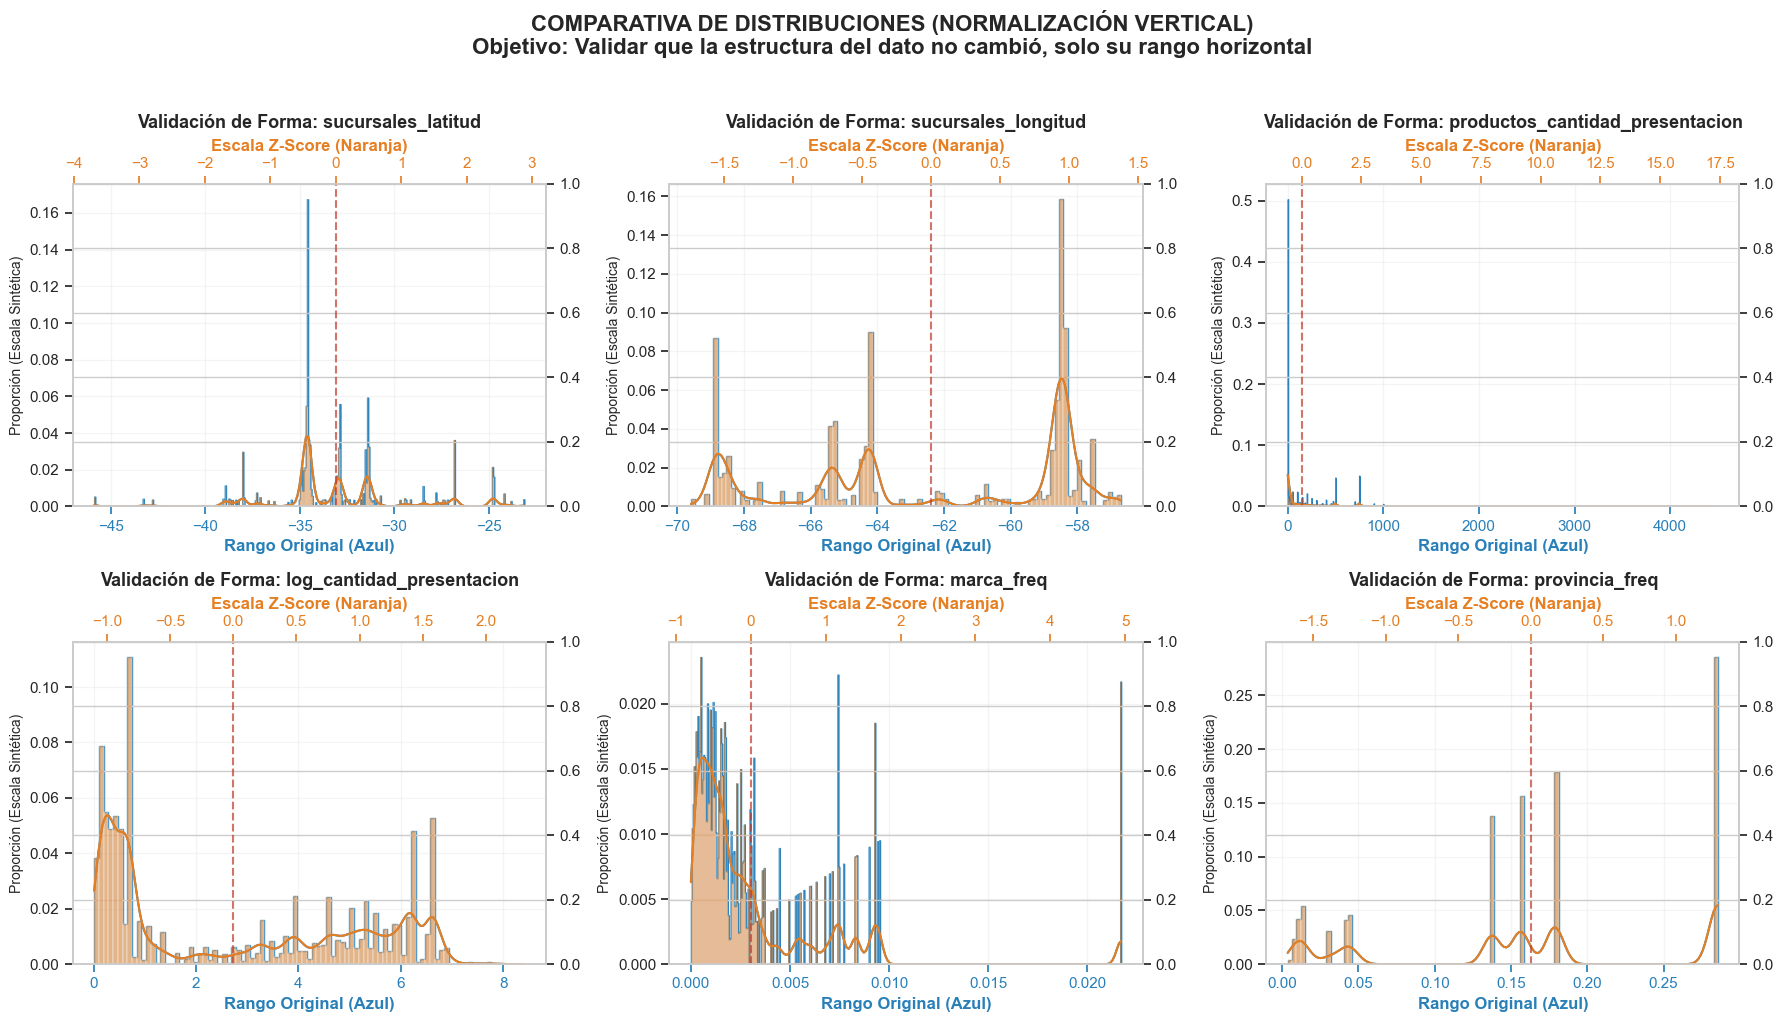

In [44]:
def plot_scaling_senior_synthetic(df_old, df_new, columns, n_cols=3):
    n_rows = (len(columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        
        # --- LÓGICA DE ESCALA SINTÉTICA (Y-axis Normalization) ---
        # Extraemos los datos para asegurar que no haya NaNs
        data_old = df_old[col].dropna()
        data_new = df_new[col].dropna()

        # Eje inferior: ORIGINAL (Azul)
        # Usamos histplot pero con un eje Y independiente oculto para que 'se vea'
        ax_alt = ax.twinx() 
        sns.histplot(data_old, color="#2980b9", kde=True, stat="proportion", 
                     element="step", fill=True, alpha=0.15, ax=ax, label="Original")
        ax.set_xlabel('Rango Original (Azul)', color='#2980b9', fontweight='bold')
        ax.tick_params(axis='x', colors='#2980b9')
        
        # Eje superior: ESTANDARIZADO (Naranja)
        ax2 = ax.twiny()
        sns.histplot(data_new, color="#e67e22", kde=True, stat="proportion", 
                     alpha=0.5, ax=ax2, label="Estandarizado")
        ax2.set_xlabel('Escala Z-Score (Naranja)', color='#e67e22', fontweight='bold')
        ax2.tick_params(axis='x', colors='#e67e22')

        # --- SINCRONIZACIÓN VISUAL ---
        # Forzamos a que ambos compartan el mismo "techo" visual en el eje Y
        # al usar stat="proportion", el área total suma 1, lo que hace las alturas comparables
        ax.set_ylabel('Proporción (Escala Sintética)', fontsize=10)
        ax2.grid(False)
        ax.grid(True, alpha=0.2)
        
        # Línea de la Media (0) en el escalado
        ax2.axvline(0, color='#c0392b', linestyle='--', alpha=0.7, lw=1.5)
        
        ax.set_title(f'Validación de Forma: {col}', fontsize=13, pad=40, fontweight='bold')

    # Limpieza de espacios sobrantes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('COMPARATIVA DE DISTRIBUCIONES (NORMALIZACIÓN VERTICAL)\n'
                 'Objetivo: Validar que la estructura del dato no cambió, solo su rango horizontal', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

# Ejecutar con tus datos
plot_scaling_senior_synthetic(X_train_num, X_train_scaled, cols_a_escalar)

---
## 9. Correlación y selección de features

### 9.1 Matriz de correlación

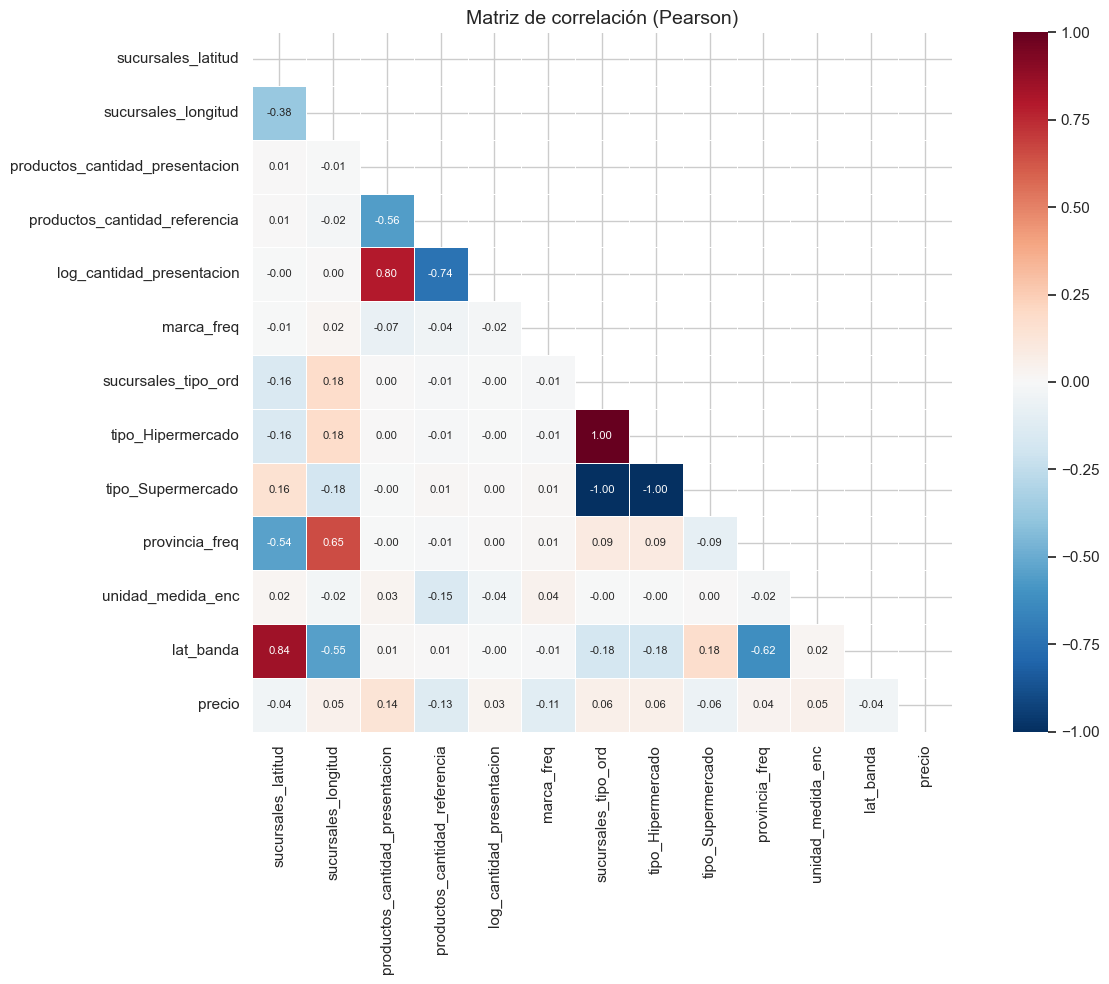

In [45]:
# Unimos features escalados con target para el análisis de correlación
df_corr = X_train_scaled.copy()
df_corr[target_col] = y_train.values

# Matriz de correlación (solo numéricas)
corr_matrix = df_corr.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlación (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()

#### 🏆 Correlación con el target

productos_cantidad_presentacion    0.1363
tipo_Hipermercado                  0.0588
sucursales_tipo_ord                0.0588
sucursales_longitud                0.0544
unidad_medida_enc                  0.0533
provincia_freq                     0.0374
log_cantidad_presentacion          0.0299
lat_banda                         -0.0352
sucursales_latitud                -0.0370
tipo_Supermercado                 -0.0588
marca_freq                        -0.1119
productos_cantidad_referencia     -0.1307
Name: precio, dtype: float64


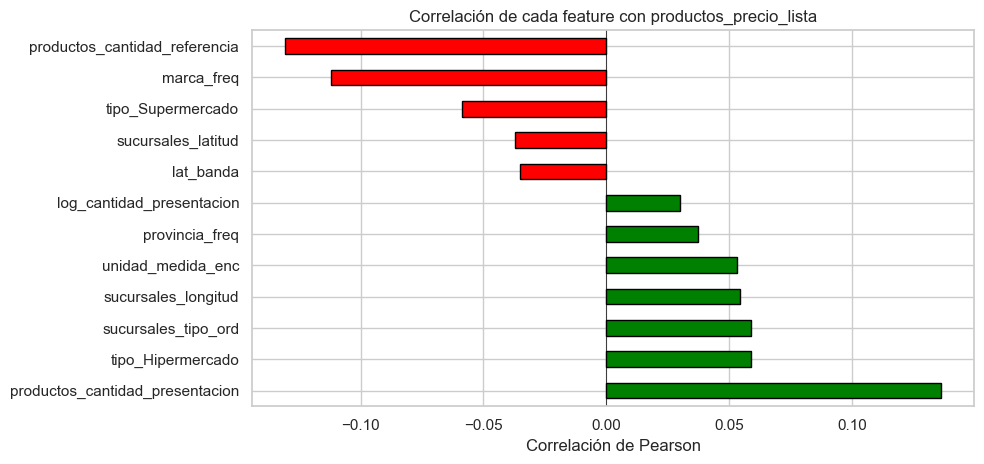

In [46]:
# Correlación de cada feature con el target
corr_target = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
display(Markdown("#### 🏆 Correlación con el target"))
print(corr_target.round(4))

fig, ax = plt.subplots(figsize=(10, max(4, len(corr_target) * 0.4)))
colors = ['green' if v > 0 else 'red' for v in corr_target]
corr_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Correlación de cada feature con productos_precio_lista')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

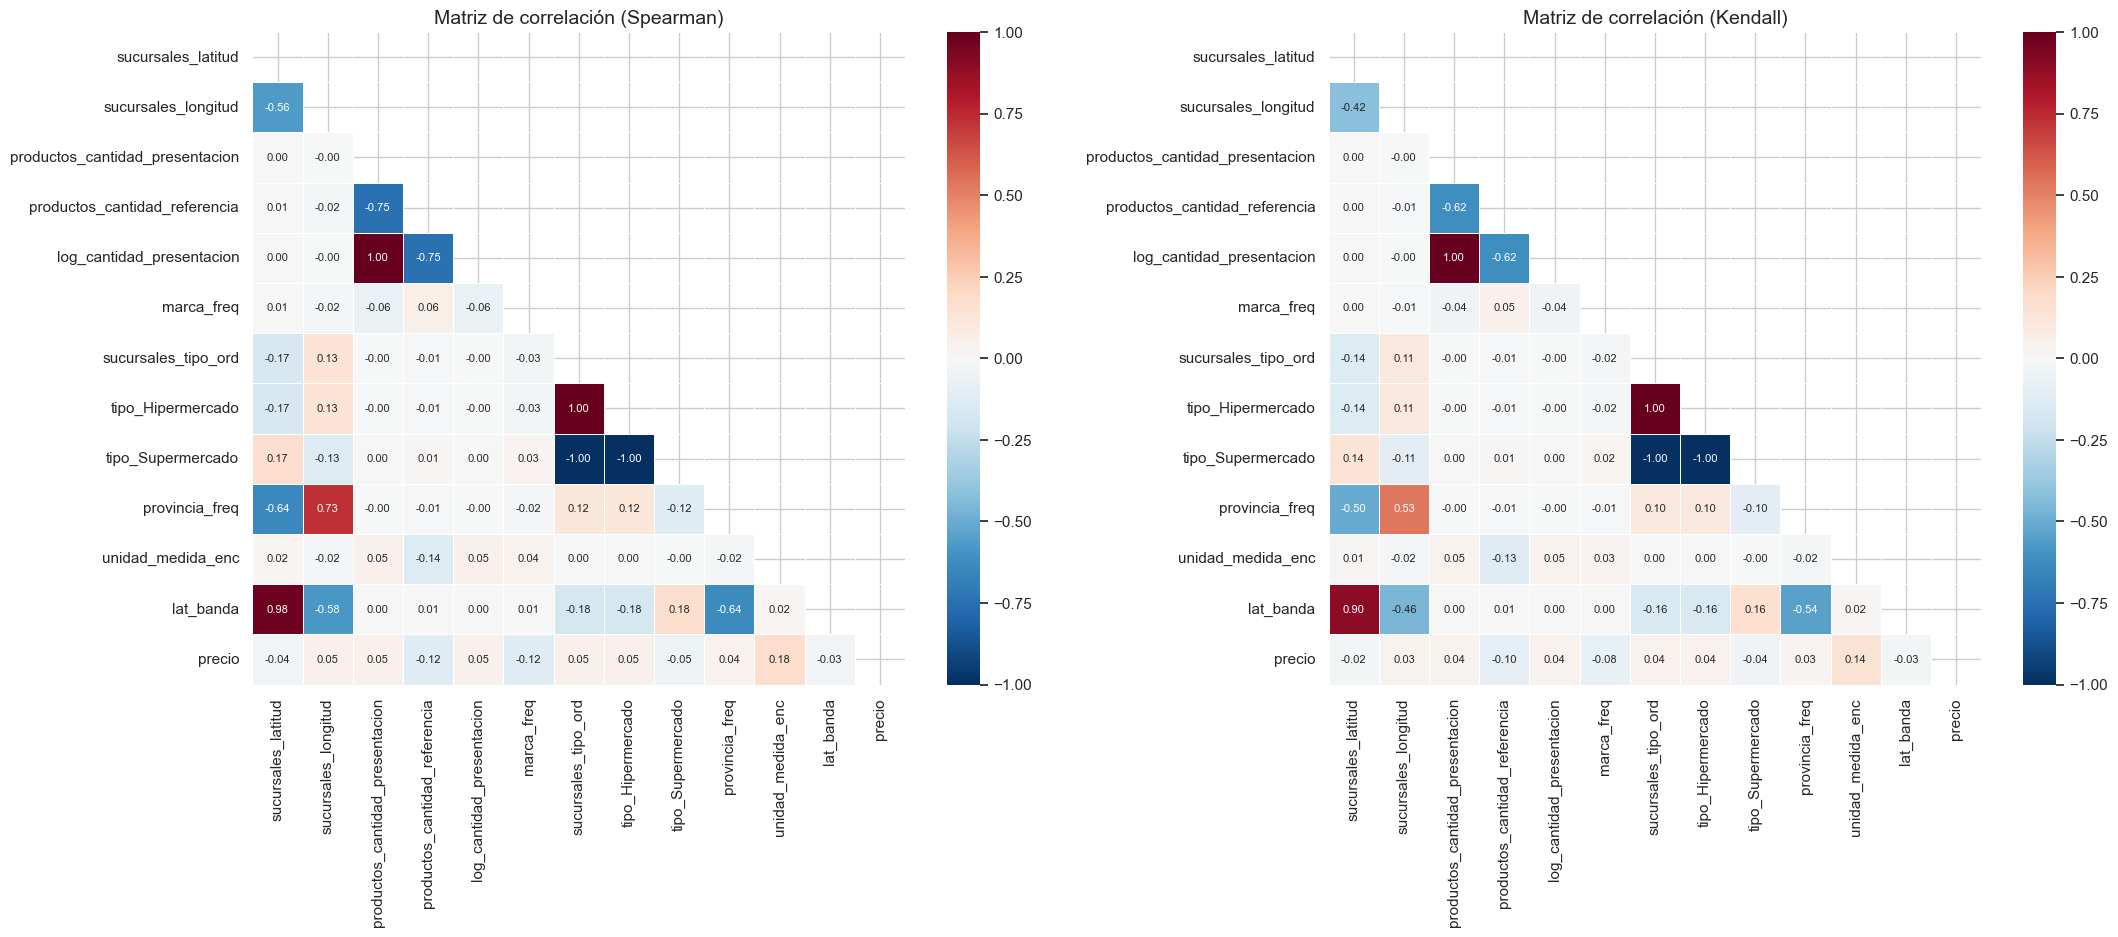

=== Correlación de Spearman con el target ===
unidad_medida_enc                  0.1823
sucursales_longitud                0.0500
log_cantidad_presentacion          0.0494
productos_cantidad_presentacion    0.0494
tipo_Hipermercado                  0.0486
sucursales_tipo_ord                0.0486
provincia_freq                     0.0422
lat_banda                         -0.0349
sucursales_latitud                -0.0359
tipo_Supermercado                 -0.0486
marca_freq                        -0.1210
productos_cantidad_referencia     -0.1211
Name: precio, dtype: float64

=== Correlación de Kendall con el target ===
unidad_medida_enc                  0.1442
tipo_Hipermercado                  0.0398
sucursales_tipo_ord                0.0398
productos_cantidad_presentacion    0.0380
log_cantidad_presentacion          0.0380
sucursales_longitud                0.0335
provincia_freq                     0.0302
sucursales_latitud                -0.0240
lat_banda                         -0.02

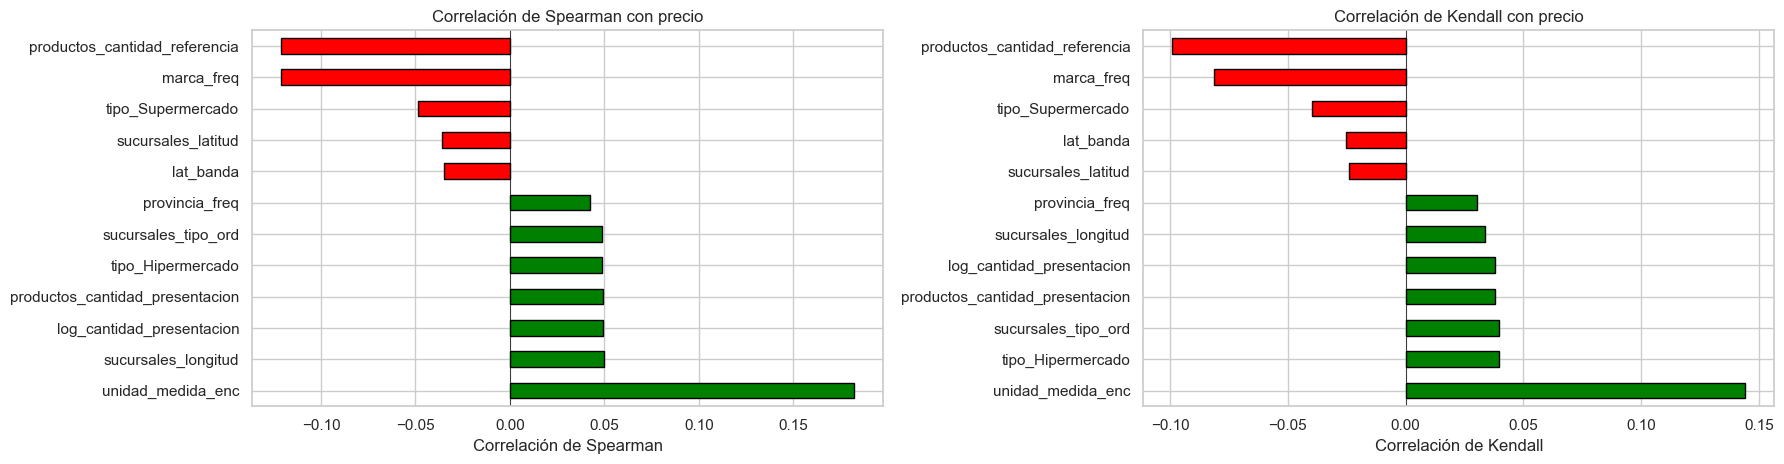

In [47]:
# ============================================================
# Spearman y Kendall: correlaciones con el target
# ============================================================
# Ambos miden relaciones MONÓTONAS (no necesariamente lineales)
# - Spearman: robusto a outliers, trabaja sobre rankings
# - Kendall:  más robusto aún, mejor con valores repetidos

corr_spearman = df_corr.select_dtypes(include=[np.number]).corr(method='spearman')
corr_kendall  = df_corr.select_dtypes(include=[np.number]).corr(method='kendall')

# Heatmaps de las matrices completas
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

mask_s = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask_s, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8})
axes[0].set_title('Matriz de correlación (Spearman)', fontsize=14)

mask_k = np.triu(np.ones_like(corr_kendall, dtype=bool))
sns.heatmap(corr_kendall, mask=mask_k, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 8})
axes[1].set_title('Matriz de correlación (Kendall)', fontsize=14)

plt.tight_layout()
plt.show()

# Correlación con el target
corr_spearman_target = corr_spearman[target_col].drop(target_col).sort_values(ascending=False)
corr_kendall_target  = corr_kendall[target_col].drop(target_col).sort_values(ascending=False)

print('=== Correlación de Spearman con el target ===')
print(corr_spearman_target.round(4))
print('\n=== Correlación de Kendall con el target ===')
print(corr_kendall_target.round(4))

# Gráfico de barras horizontales
fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(corr_spearman_target) * 0.4)))

colors_s = ['green' if v > 0 else 'red' for v in corr_spearman_target]
corr_spearman_target.plot(kind='barh', ax=axes[0], color=colors_s, edgecolor='black')
axes[0].set_title(f'Correlación de Spearman con {target_col}')
axes[0].set_xlabel('Correlación de Spearman')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

colors_k = ['green' if v > 0 else 'red' for v in corr_kendall_target]
corr_kendall_target.plot(kind='barh', ax=axes[1], color=colors_k, edgecolor='black')
axes[1].set_title(f'Correlación de Kendall con {target_col}')
axes[1].set_xlabel('Correlación de Kendall')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

### 9.2 Selección de features con filtros (SelectKBest con f_regression)

🎖 Top 10 features por F-score


,feature,f_score,p_value
2,productos_cantidad_presentacion,21600.216422,0.000000e+00
3,productos_cantidad_referencia,19821.423618,0.000000e+00
5,marca_freq,14481.648517,0.000000e+00
7,tipo_Hipermercado,3959.216526,0.000000e+00
6,sucursales_tipo_ord,3959.216526,0.000000e+00
8,tipo_Supermercado,3959.216526,0.000000e+00
1,sucursales_longitud,3392.004013,0.000000e+00
10,unidad_medida_enc,3248.503588,0.000000e+00
9,provincia_freq,1597.751679,0.000000e+00
0,sucursales_latitud,1561.724871,0.000000e+00


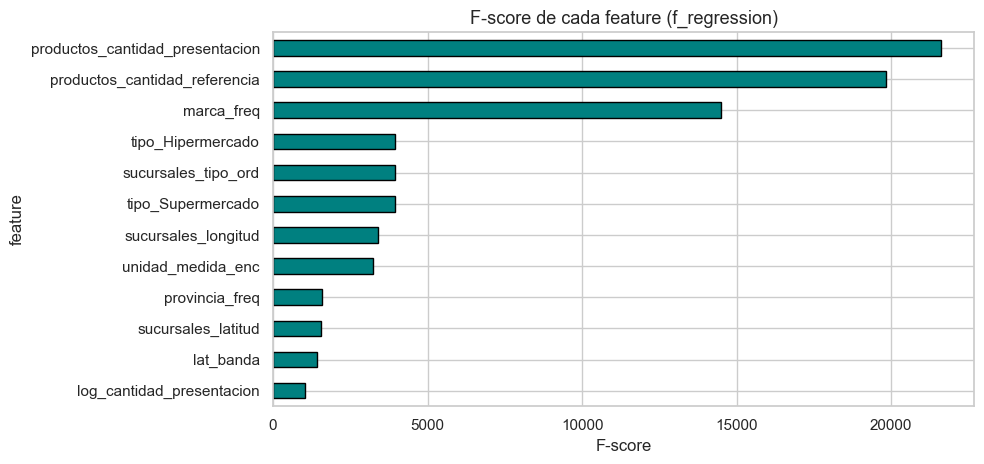

In [48]:
# Preparar datos para selección (sin NaN)
X_sel = X_train_scaled.select_dtypes(include=[np.number]).dropna()
y_sel = y_train.loc[X_sel.index]

# SelectKBest con f_regression
k = min(10, X_sel.shape[1])
selector = SelectKBest(f_regression, k=k)   # usamos f_regression porque la v.target es numérica
selector.fit(X_sel, y_sel)

scores = pd.DataFrame({
    'feature': X_sel.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

print(f'🎖 Top {k} features por F-score')
display(scores)

# Visualización
fig, ax = plt.subplots(figsize=(10, max(4, len(scores) * 0.4)))
scores_plot = scores.set_index('feature')['f_score'].sort_values()
scores_plot.plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_title('F-score de cada feature (f_regression)', fontsize=13)
ax.set_xlabel('F-score')
plt.tight_layout()
plt.show()

=== Mutual Information con el target ===


,feature,mutual_info
5,marca_freq,2.664729
4,log_cantidad_presentacion,1.488832
2,productos_cantidad_presentacion,1.488377
10,unidad_medida_enc,0.306776
1,sucursales_longitud,0.146213
0,sucursales_latitud,0.145190
9,provincia_freq,0.139247
3,productos_cantidad_referencia,0.092410
11,lat_banda,0.067829
8,tipo_Supermercado,0.013570


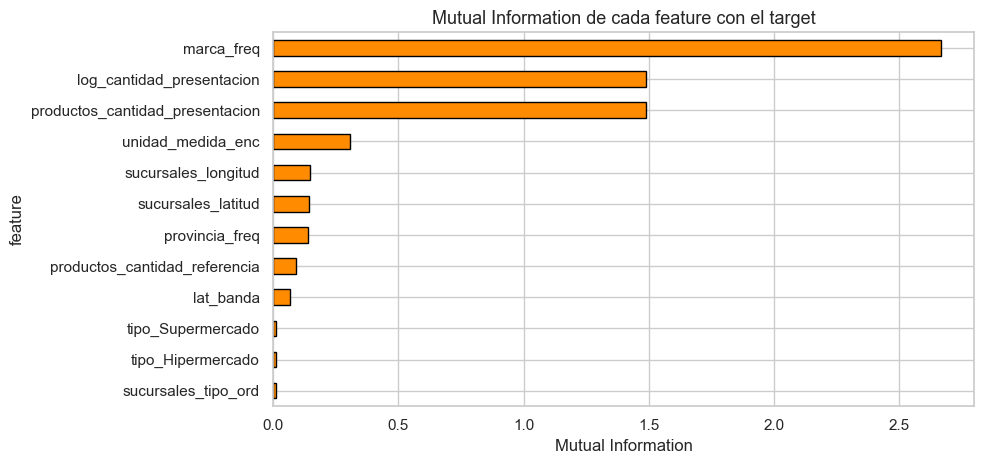

In [49]:
# Selección con Mutual Information (captura relaciones no lineales)
mi_scores = mutual_info_regression(X_sel, y_sel, random_state=42)

mi_df = pd.DataFrame({
    'feature': X_sel.columns,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print('=== Mutual Information con el target ===')
display(mi_df)

fig, ax = plt.subplots(figsize=(10, max(4, len(mi_df) * 0.4)))
mi_df_plot = mi_df.set_index('feature')['mutual_info'].sort_values()
mi_df_plot.plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Mutual Information de cada feature con el target', fontsize=13)
ax.set_xlabel('Mutual Information')
plt.tight_layout()
plt.show()

=== Tabla de decisión ===


,feature,pearson_abs,spearman_abs,kendall_abs,f_score,p_value,mutual_info,rank_pearson_abs,rank_spearman_abs,rank_kendall_abs,rank_f_score,rank_mutual_info,rank_promedio
0,marca_freq,0.1119,0.1210,0.0813,14481.6485,0.0,2.6647,3.0,3.0,3.0,3.0,1.0,2.6
1,productos_cantidad_referencia,0.1307,0.1211,0.0991,19821.4236,0.0,0.0924,2.0,2.0,2.0,2.0,8.0,3.2
2,productos_cantidad_presentacion,0.1363,0.0494,0.0380,21600.2164,0.0,1.4884,1.0,5.5,7.5,1.0,3.0,3.6
3,unidad_medida_enc,0.0533,0.1823,0.1442,3248.5036,0.0,0.3068,8.0,1.0,1.0,8.0,4.0,4.4
4,tipo_Hipermercado,0.0588,0.0486,0.0398,3959.2165,0.0,0.0134,4.0,8.0,5.0,4.0,11.0,6.4
5,sucursales_longitud,0.0544,0.0500,0.0335,3392.0040,0.0,0.1462,7.0,4.0,9.0,7.0,5.0,6.4
6,tipo_Supermercado,0.0588,0.0486,0.0398,3959.2165,0.0,0.0136,5.0,8.0,5.0,6.0,10.0,6.8
7,sucursales_tipo_ord,0.0588,0.0486,0.0398,3959.2165,0.0,0.0127,6.0,8.0,5.0,5.0,12.0,7.2
8,log_cantidad_presentacion,0.0299,0.0494,0.0380,1021.0672,0.0,1.4888,12.0,5.5,7.5,12.0,2.0,7.8
9,provincia_freq,0.0374,0.0422,0.0302,1597.7517,0.0,0.1392,9.0,10.0,10.0,9.0,7.0,9.0


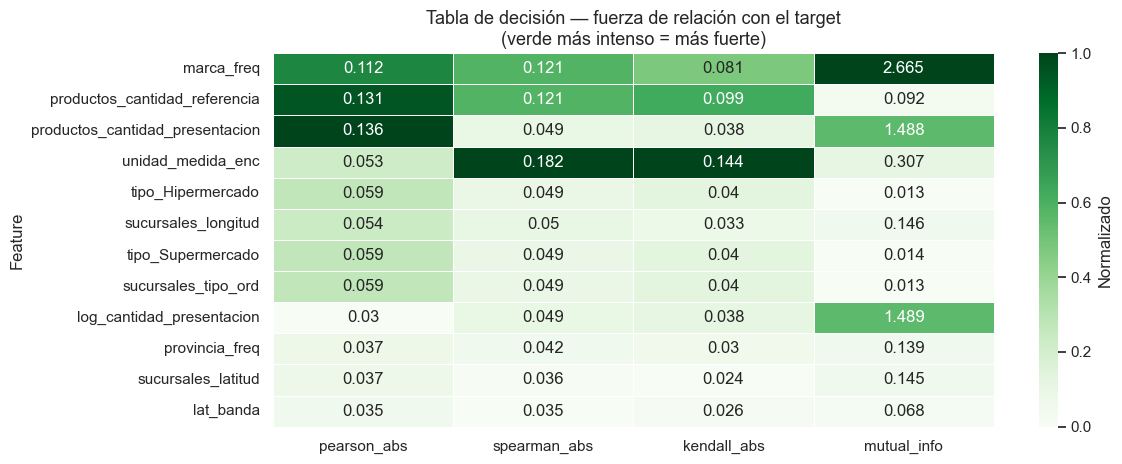

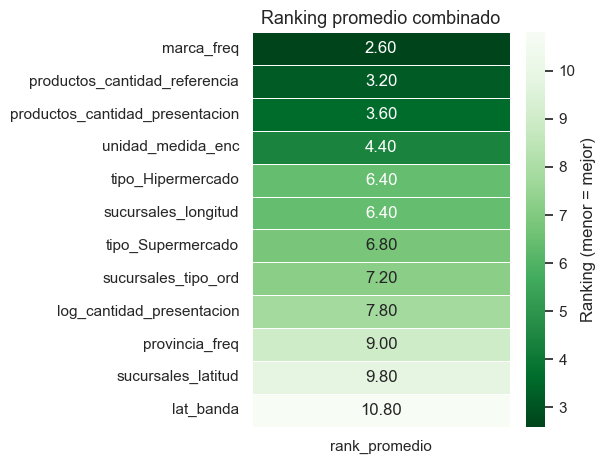

In [50]:
# ============================================================
# Tabla combinada de decisión: todos los métodos en una vista
# ============================================================
tabla_decision = pd.DataFrame({'feature': X_sel.columns})

# Valores absolutos de correlaciones (para comparar fuerza, no dirección)
tabla_decision['pearson_abs']  = corr_target.abs().reindex(X_sel.columns).values
tabla_decision['spearman_abs'] = corr_spearman_target.abs().reindex(X_sel.columns).values
tabla_decision['kendall_abs']  = corr_kendall_target.abs().reindex(X_sel.columns).values
tabla_decision['f_score']      = scores.set_index('feature').loc[X_sel.columns, 'f_score'].values
tabla_decision['p_value']      = scores.set_index('feature').loc[X_sel.columns, 'p_value'].values
tabla_decision['mutual_info']  = mi_df.set_index('feature').loc[X_sel.columns, 'mutual_info'].values

# Rankings individuales (1 = mejor)
for col in ['pearson_abs', 'spearman_abs', 'kendall_abs', 'f_score', 'mutual_info']:
    tabla_decision[f'rank_{col}'] = tabla_decision[col].rank(ascending=False)

# Ranking combinado: promedio de los 5 rankings
rank_cols = [c for c in tabla_decision.columns if c.startswith('rank_')]
tabla_decision['rank_promedio'] = tabla_decision[rank_cols].mean(axis=1)

tabla_decision = tabla_decision.sort_values('rank_promedio').reset_index(drop=True)

# Mostrar la tabla sin estilo
print('=== Tabla de decisión ===')
display(tabla_decision.round(4))

# Visualización tipo heatmap con seaborn
fig, ax = plt.subplots(figsize=(12, max(4, len(tabla_decision) * 0.4)))

# Seleccionamos solo las columnas numéricas de "fuerza" para visualizar
cols_fuerza = ['pearson_abs', 'spearman_abs', 'kendall_abs', 'mutual_info']
heatmap_data = tabla_decision.set_index('feature')[cols_fuerza]

# Normalizamos cada columna a [0, 1] para que el color sea comparable
heatmap_norm = heatmap_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

sns.heatmap(heatmap_norm, annot=heatmap_data.round(3), fmt='',
            cmap='Greens', linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalizado'})
ax.set_title('Tabla de decisión — fuerza de relación con el target\n(verde más intenso = más fuerte)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# Segundo heatmap: ranking promedio
fig, ax = plt.subplots(figsize=(6, max(4, len(tabla_decision) * 0.4)))
ranking_data = tabla_decision.set_index('feature')[['rank_promedio']]
sns.heatmap(ranking_data, annot=True, fmt='.2f', cmap='Greens_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Ranking (menor = mejor)'})
ax.set_title('Ranking promedio combinado', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Como resultado de utilizar el método "Mutual Information", vemos que los features *marca_freq* , *log_cantidad_presentacion* y *productos_cantidad_presentacion* muestran una alta relevancia y relacion con la v.target

Por otro lado, los features *tipo_hipermercado* , *tipo_supermercado* y *sucursales_tipo_ord* tienen una infima relación con la v.target, por tanto son candidatas a ser removidas para lograr una reducción de dimensionalidad

In [51]:
# --- Seleccionamos las columnas a eliminar ---
cols_to_drop = [
    'tipo_Hipermercado', 'tipo_Supermercado', 'sucursales_tipo_ord'
]
cols_to_drop = [c for c in cols_to_drop if c in X_sel.columns]

X_sel = X_sel.drop(columns=cols_to_drop)
X_sel.head()


,sucursales_latitud,sucursales_longitud,productos_cantidad_presentacion,productos_cantidad_referencia,log_cantidad_presentacion,marca_freq,provincia_freq,unidad_medida_enc,lat_banda
1088455,-0.529491,1.065839,1.221725,1,1.372307,-0.698802,1.287854,5,0
359838,-0.421357,0.950781,2.421692,1,1.579032,-0.789487,0.164844,3,2
1245053,-0.430059,0.960806,-0.577745,100,-1.059293,-0.525782,0.164844,5,1
1162483,0.054809,-1.554446,-0.577825,100,-1.066597,-0.108538,-0.266614,5,3
569002,0.068080,-1.562562,-0.546226,1,-0.214497,-0.334902,-0.266614,12,3


---
## 10. Reducción de dimensionalidad a través de métodos de Extracción (PCA)

### Evaluación de PCA

Consideramos PCA como posible técnica de extracción de features y reducción de dimensionalidad.

**Ventajas:**
- Reduce la dimensionalidad del espacio de features.
- Elimina correlaciones lineales entre variables.
- Puede mejorar el rendimiento en modelos sensibles a la dimensionalidad (e.g., KNN).

**Desventajas:**
- Se pierde la interpretabilidad de los features originales.
- No siempre mejora modelos basados en árboles (que son robustos a features redundantes).
- Sensible a la escala (requiere estandarización previa, ya realizada).

La siguiente tabla lo ilustra comparando contra métodos de selección:

| Aspecto             |             Seleccion            |    Extraccion (ej PCA)   | 
| ------------------- | -------------------------------- | ------------------------ |
| En que consiste     |  Conservar un subconjunto de las variables originales (las mas relevantes) | Crear nuevas variables (componentes) combinando las originales |
| En que tipo de datasets aplicarlo |    Dimensionalidad moderada      |   Dimensionalidad alta   |
| Interpretabilidad |           Alta |           Baja |
| Técnicas | Correlación con la v.target - Correlación pairwise - ANOVA - Chi-cuadrado - Información mutua - otras | PCA - LDA - t-SNE - UMAP - otras |

De acuerdo a las características del dataset obtenido hasta ahora, sabemos que su dimensión es 8 (moderada).
Ademas, en pos de trabajar con un dataset con significado y facil de leer e interpretar, nos inclinamos por mantener la interpretabilidad de los datos.

**Conclusión:**
Esto nos lleva a elegir técnicas de *selección* por sobre la extracción. Es decir, descartamos el método PCA por las razones expuestas.

## 11. Dataset final preparado

Resumen del pipeline de preparación aplicado:

---



#### 1. Carga y Unión *(sección 1)*

* Integración de **3 archivos CSV** mediante claves `id_comercio`, `id_bandera`, `id_sucursal`
* Dataset resultante:

In [52]:
print(f"{len(df):,} filas × {df.shape[1]} columnas")

1,426,356 filas × 31 columnas


* Incorporación de **features sintéticas**: `provincia_nombre` y `provincia_region`
* Prevención de **Target Leakage**: eliminación de `productos_precio_referencia`

---

#### 2. Análisis de Valores Faltantes *(sección 2)*

* Clasificación de faltantes según mecanismo: **MCAR / MAR / MNAR**
* Remoción de **features constantes** (varianza cero)

> **Nota:** El Análisis Exploratorio de Datos (sección 3) no forma parte del pipeline de preparación, pero es prerrequisito para fundamentar las decisiones de las etapas siguientes.

---

#### 3. Errores, Inconsistencias y Outliers *(sección 4)*

* Eliminación de registros con `precio ≤ 0` *(errores de carga)*
* Tratamiento de outliers: **Capping** en el rango **[P1, P99]**

---

#### 4. Preprocesamiento *(sección 6)*

* Selección de columnas relevantes para el modelo
* Imputación de variables geográficas (`lat`, `long`) por **mediana a nivel provincia** *(supuesto MAR)*
* Imputación de variables categóricas por **moda** o **valor constante**
* Variables de promociones excluidas del modelo *(MNAR estructural)*
* Split **train / test**:

In [53]:
print(f"Train: {X_train_scaled.shape[0]:,} filas × {X_train_scaled.shape[1]} features")
print(f"Test:  {X_test_scaled.shape[0]:,} filas × {X_test_scaled.shape[1]} features")

Train: 1,141,071 filas × 13 features
Test:  285,268 filas × 13 features


---

#### 5. Feature Engineering *(sección 7)*

* Transformaciones: `log(cantidad_presentacion)`
* Variables derivadas: `es_ean` *(indicador binario)*
* Codificación **Ordinal**: `sucursales_tipo`
* Codificación **One-Hot**: tipos de sucursal
* Codificación **Label**: unidad de medida
* **Frequency Encoding**: marca (`marca_freq`), provincia (`provincia_freq`)
* Discretización: `latitud` en **5 bandas**

---

#### 6. Escalado *(sección 8)*

* **StandardScaler (z-score)**: `fit` sobre train → `transform` sobre train y test

---

#### 7. Selección de Features *(sección 9)*

* **Variance Threshold** — eliminación de baja varianza
* **Correlación de Pearson**
* **F-score** (`f_regression`)
* **Mutual Information**

---

#### 8. Reducción de Dimensionalidad *(sección 10)*

* **PCA (Principal Component Analysis)**

---

#### 🎯 Variable Objetivo

* `productos_precio_lista` *(problema de regresión)*

---

In [54]:
# Vista final del dataset preparado
print('=== X_train (escalado) — primeras filas ===')
display(X_train_scaled.head())
print(f'\nShape: {X_train_scaled.shape}')
print(f'Tipos: {X_train_scaled.dtypes.value_counts().to_dict()}')
print(f'Faltantes: {X_train_scaled.isnull().sum().sum()}')

=== X_train (escalado) — primeras filas ===


,sucursales_latitud,sucursales_longitud,productos_cantidad_presentacion,productos_cantidad_referencia,productos_unidad_medida_referencia,log_cantidad_presentacion,marca_freq,sucursales_tipo_ord,tipo_Hipermercado,tipo_Supermercado,provincia_freq,unidad_medida_enc,lat_banda
1088455,-0.529491,1.065839,1.221725,1,KG.,1.372307,-0.698802,1,0,1,1.287854,5,0
359838,-0.421357,0.950781,2.421692,1,LT.,1.579032,-0.789487,1,0,1,0.164844,3,2
1245053,-0.430059,0.960806,-0.577745,100,gr.,-1.059293,-0.525782,1,0,1,0.164844,5,1
1162483,0.054809,-1.554446,-0.577825,100,gr.,-1.066597,-0.108538,1,0,1,-0.266614,5,3
569002,0.068080,-1.562562,-0.546226,1,un.,-0.214497,-0.334902,1,0,1,-0.266614,12,3



Shape: (1141071, 13)
Tipos: {dtype('float64'): 6, dtype('int64'): 6, dtype('O'): 1}
Faltantes: 0


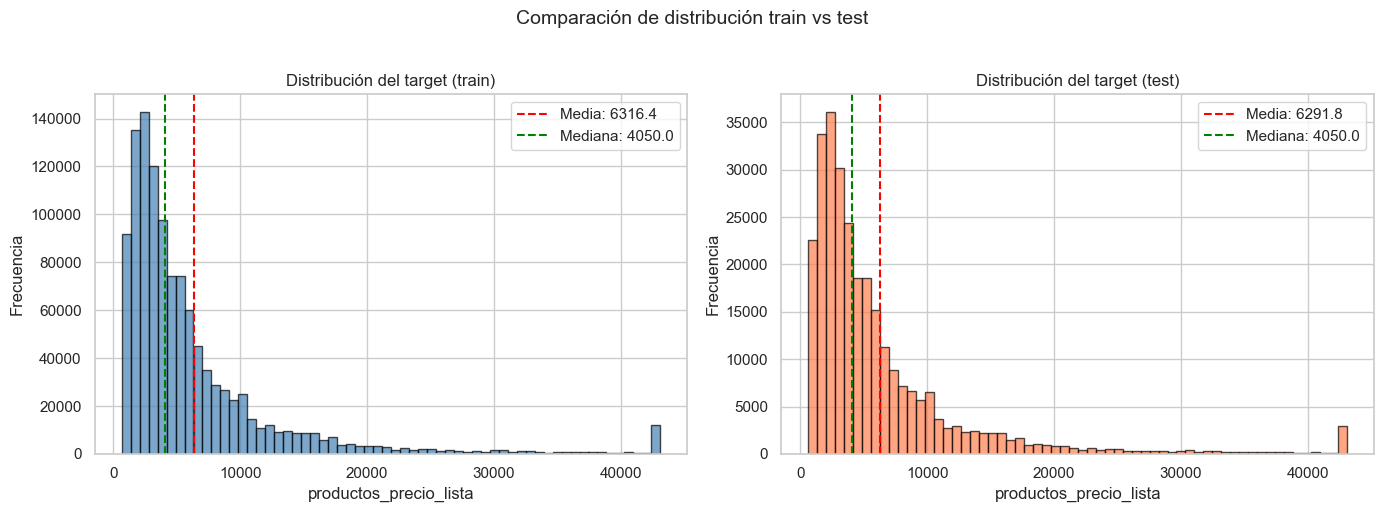

Train — Media: 6316.38, Mediana: 4050.00
Test  — Media: 6291.76, Mediana: 4050.00


In [55]:
# Distribución final del target (train)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Media: {y_train.mean():.1f}')
axes[0].axvline(y_train.median(), color='green', linestyle='--', label=f'Mediana: {y_train.median():.1f}')
axes[0].set_title('Distribución del target (train)')
axes[0].set_xlabel('productos_precio_lista')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(y_test, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(y_test.mean(), color='red', linestyle='--', label=f'Media: {y_test.mean():.1f}')
axes[1].axvline(y_test.median(), color='green', linestyle='--', label=f'Mediana: {y_test.median():.1f}')
axes[1].set_title('Distribución del target (test)')
axes[1].set_xlabel('productos_precio_lista')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Comparación de distribución train vs test', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Train — Media: {y_train.mean():.2f}, Mediana: {y_train.median():.2f}')
print(f'Test  — Media: {y_test.mean():.2f}, Mediana: {y_test.median():.2f}')

---
## 12. Conclusiones

1. **Dataset SEPA:** Contiene ~1.4M de registros de precios de productos de la cadena Vea (Cencosud) en ~271 sucursales distribuidas por todo el país.

2. **Calidad de datos:** Se identificaron valores faltantes estructurales (campos opcionales de SEPA como promociones, barrio, observaciones) y operacionales (coordenadas de sucursales web). Los tipos de faltantes fueron clasificados como MNAR y MAR según su origen.

3. **Variables más informativas:** La cantidad de presentación (y su log), la marca del producto (codificada por frecuencia), y la ubicación geográfica de la sucursal son los predictores más relevantes del precio de lista.

4. **Outliers:** La distribución de precios es fuertemente asimétrica (leptocúrtica). Se aplicó winsorización al [P1, P99] para mitigar el efecto de valores extremos sin perder registros.

5. **Feature engineering:** Se crearon features derivados (log-transform, indicadores binarios, frecuencias, bandas latitudinales) que enriquecen la representación del problema.

6. **PCA:** Consideramos PCA como posible técnica de extracción de features y reducción de dimensionalidad, y esto nos llevo a elegir técnicas de *selección* por sobre la extracción. Es decir, descartamos el método PCA por ser el dataset obtenido de dimensión 8 (moderada) e inclinarnos por mantener la interpretabilidad de los datos.

7. **Dataset listo:** El pipeline genera conjuntos train/test con features numéricos, escalados y sin faltantes, listos para alimentar un modelo de regresión supervisada.

---
*TP realizado para Análisis de Datos 1B 2026 — FIUBA-CEIA*